# Power scan — harmonic fluctuation model

Sweep the **pump power** for one fixed configuration (filter + polarisation) and test how the
photon statistics of each harmonic depend on the driving intensity $I_0$. One acquisition file
per power.

This notebook is **self-contained and reusable**: point it at a power-scan folder, choose an
integration window, and it produces the full diagnostic suite (`PowerScanAnalyzer`).

In [1]:
import numpy as np
from pathlib import Path

import os
import sys
project_root = os.path.abspath('../../')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.hbt_core import HBTMeasurement
from src.hbt_visu import GridVisualizer
from src.hbt_powerscan import PowerScanAnalyzer

## 1. Discover the power scan

Set `SCAN_DIR` to the folder holding one merged file per power
(`MERGED/*_MERGED.pkl`, with a single-chunk fallback). Runs are sorted by increasing power.

In [2]:
SCAN_DIR = Path(project_root) / "data/Jun17/PowerScan_GaAs100_noP1"

run_files = sorted(SCAN_DIR.glob("MERGED/*_MERGED.pkl"))
if not run_files:
    run_files = sorted(SCAN_DIR.glob("*chunk0.pkl"))
assert run_files, f"No runs found under {SCAN_DIR}"

runs = sorted([HBTMeasurement(f) for f in run_files], key=lambda r: r.power_mw)
print(f"Discovered {len(runs)} power(s) in {SCAN_DIR}:")
print(f"  sample = {runs[0].material} | lambda = {runs[0].wavelength_nm} nm | "
      f"filter = {runs[0].filter_label} | pol = {runs[0].polarization}")
print(f"  powers (mW): {[r.power_mw for r in runs]}")
print(f"  physical histograms: {all(r.has_physical_histograms for r in runs)}")

Discovered 7 power(s) in /Users/simon.wtmn/Desktop/Quantum_SHHG/data/Jun17/PowerScan_GaAs100_noP1:
  sample = GaAs100_100um_noP1 | lambda = 2100 nm | filter = None | pol = None
  powers (mW): [19.16, 22.83, 27.39, 32.68, 38.63, 54.97, 71.95]
  physical histograms: True


## 2. Choose the integration window $\tau_{in}$

The $g^{(2)}$ is read with the **delay** method (peak-area ratio), which needs an integration
window. Overlay the $g^{(2)}$ vs $\tau_{in}$ sweep across powers for one auto pair and pick a
value on the plateau, then set `TAU_INT`.

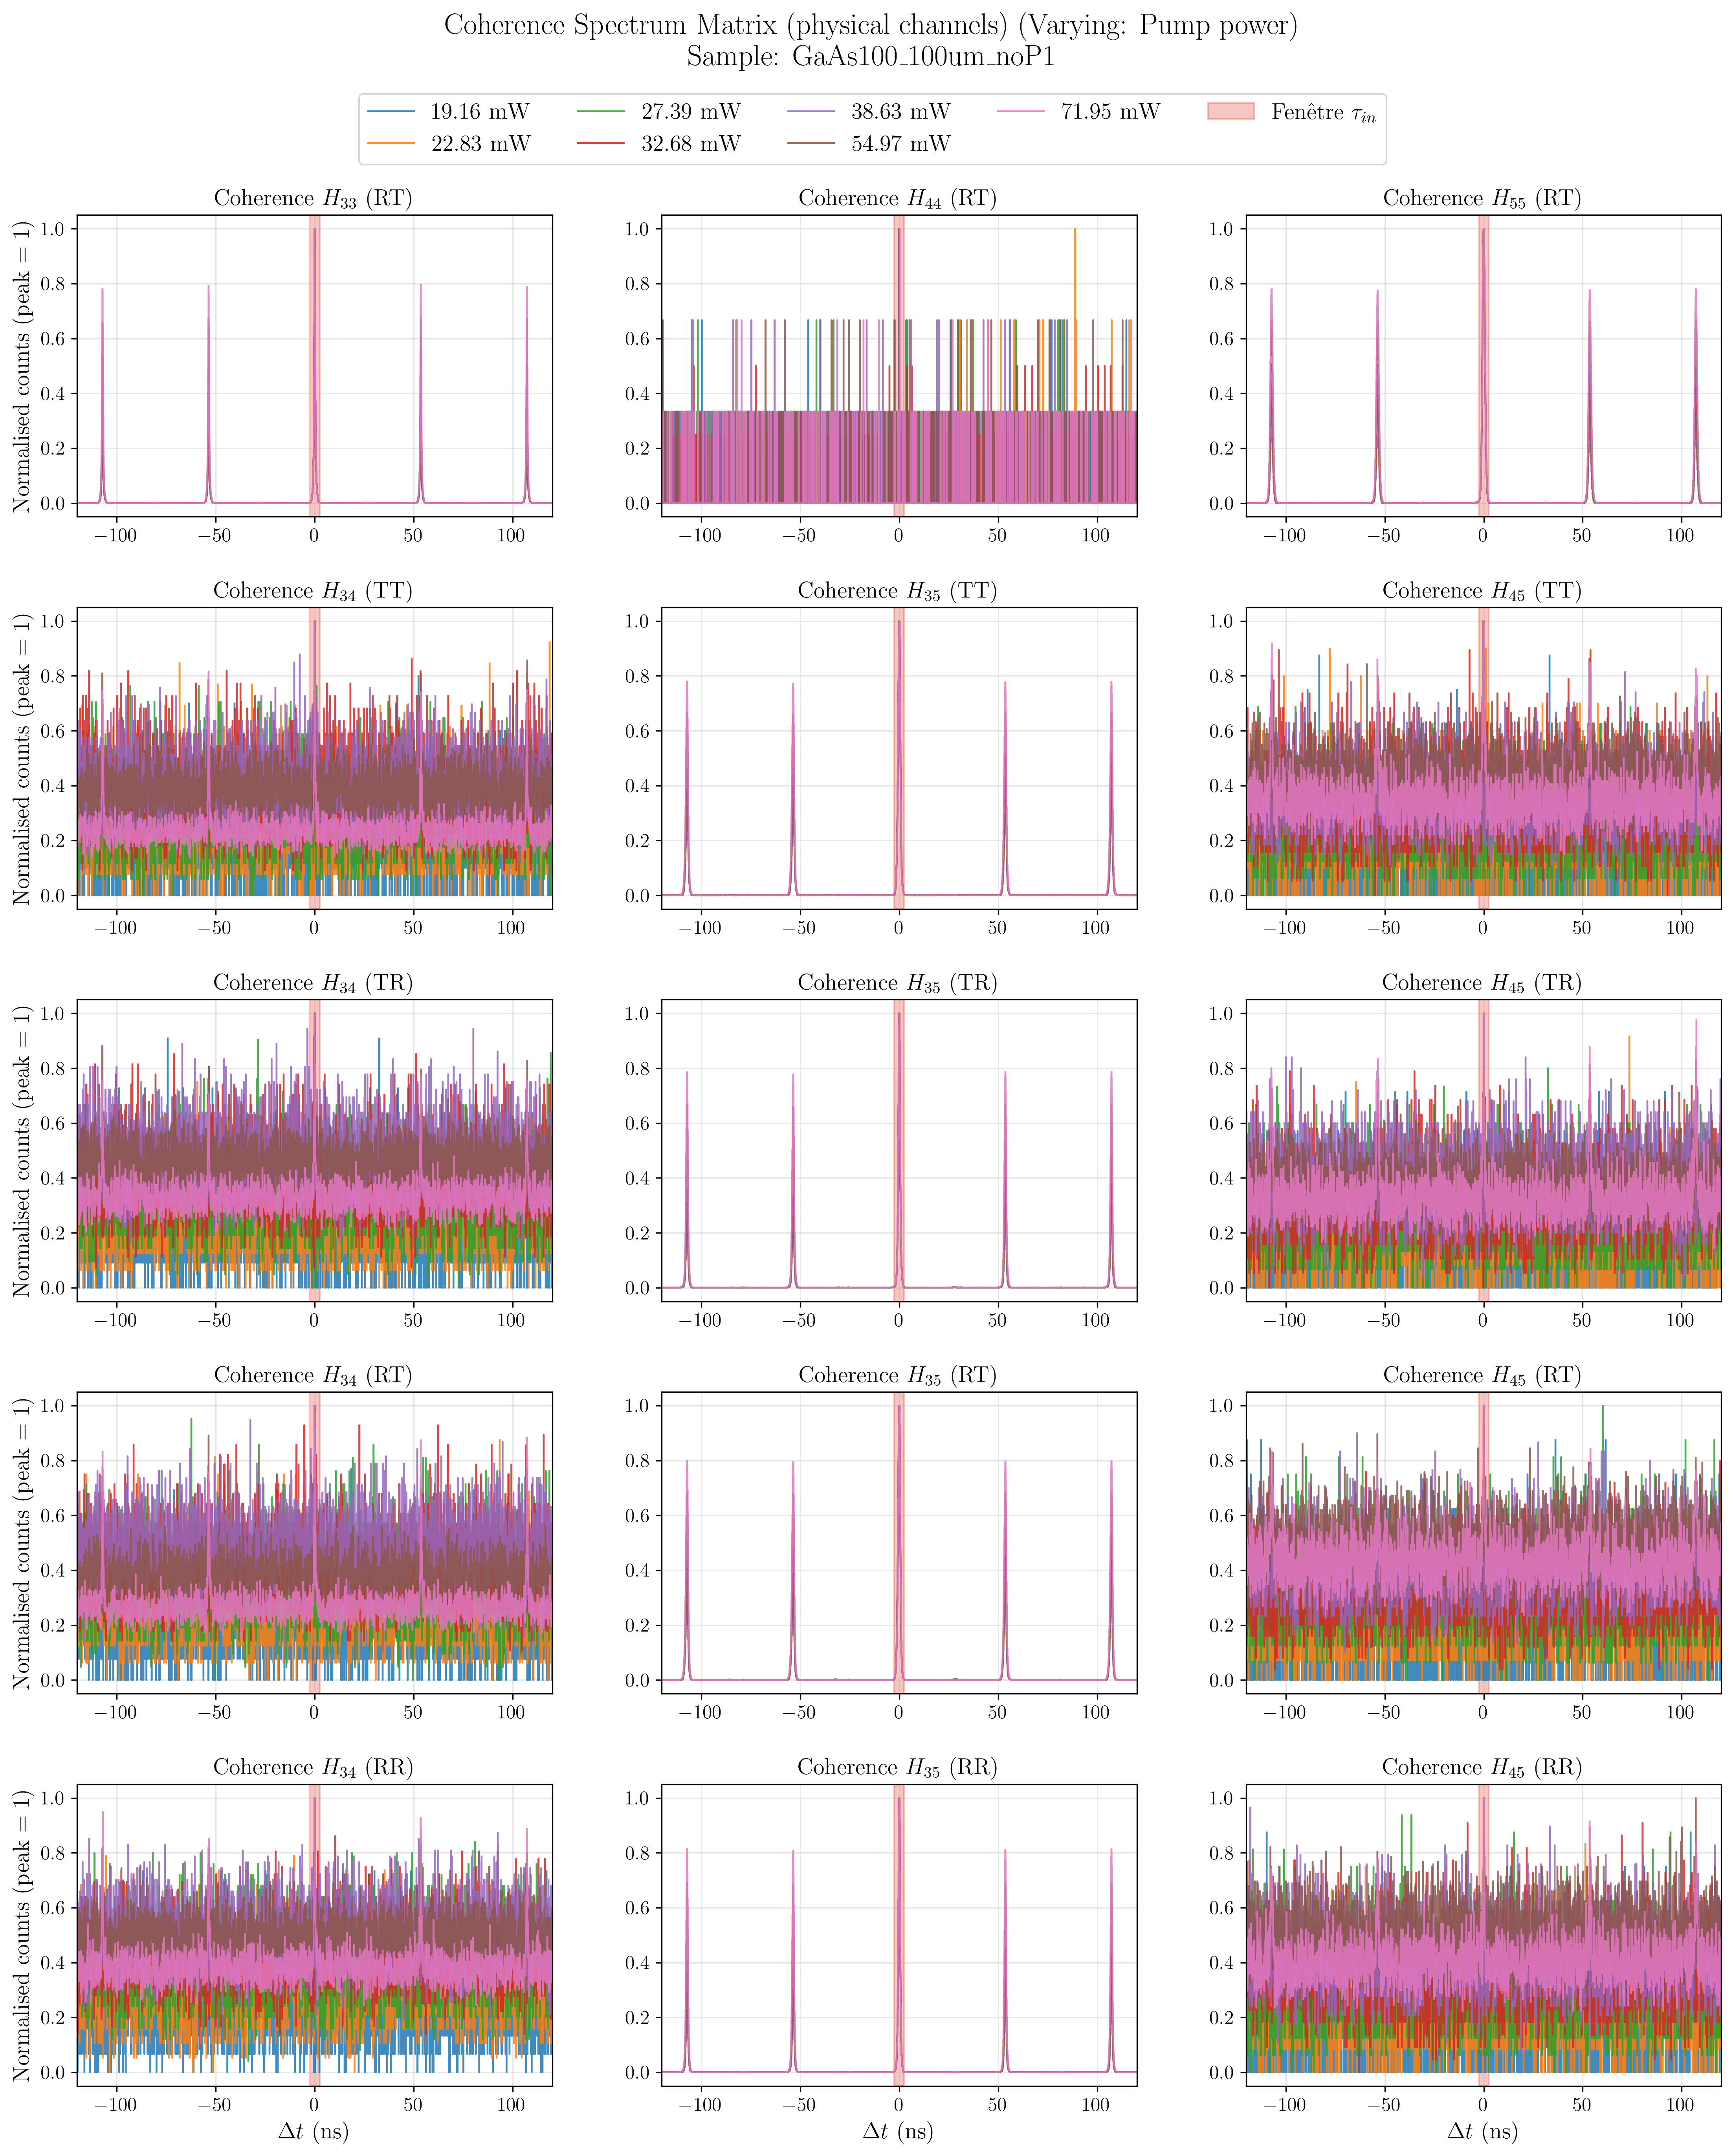

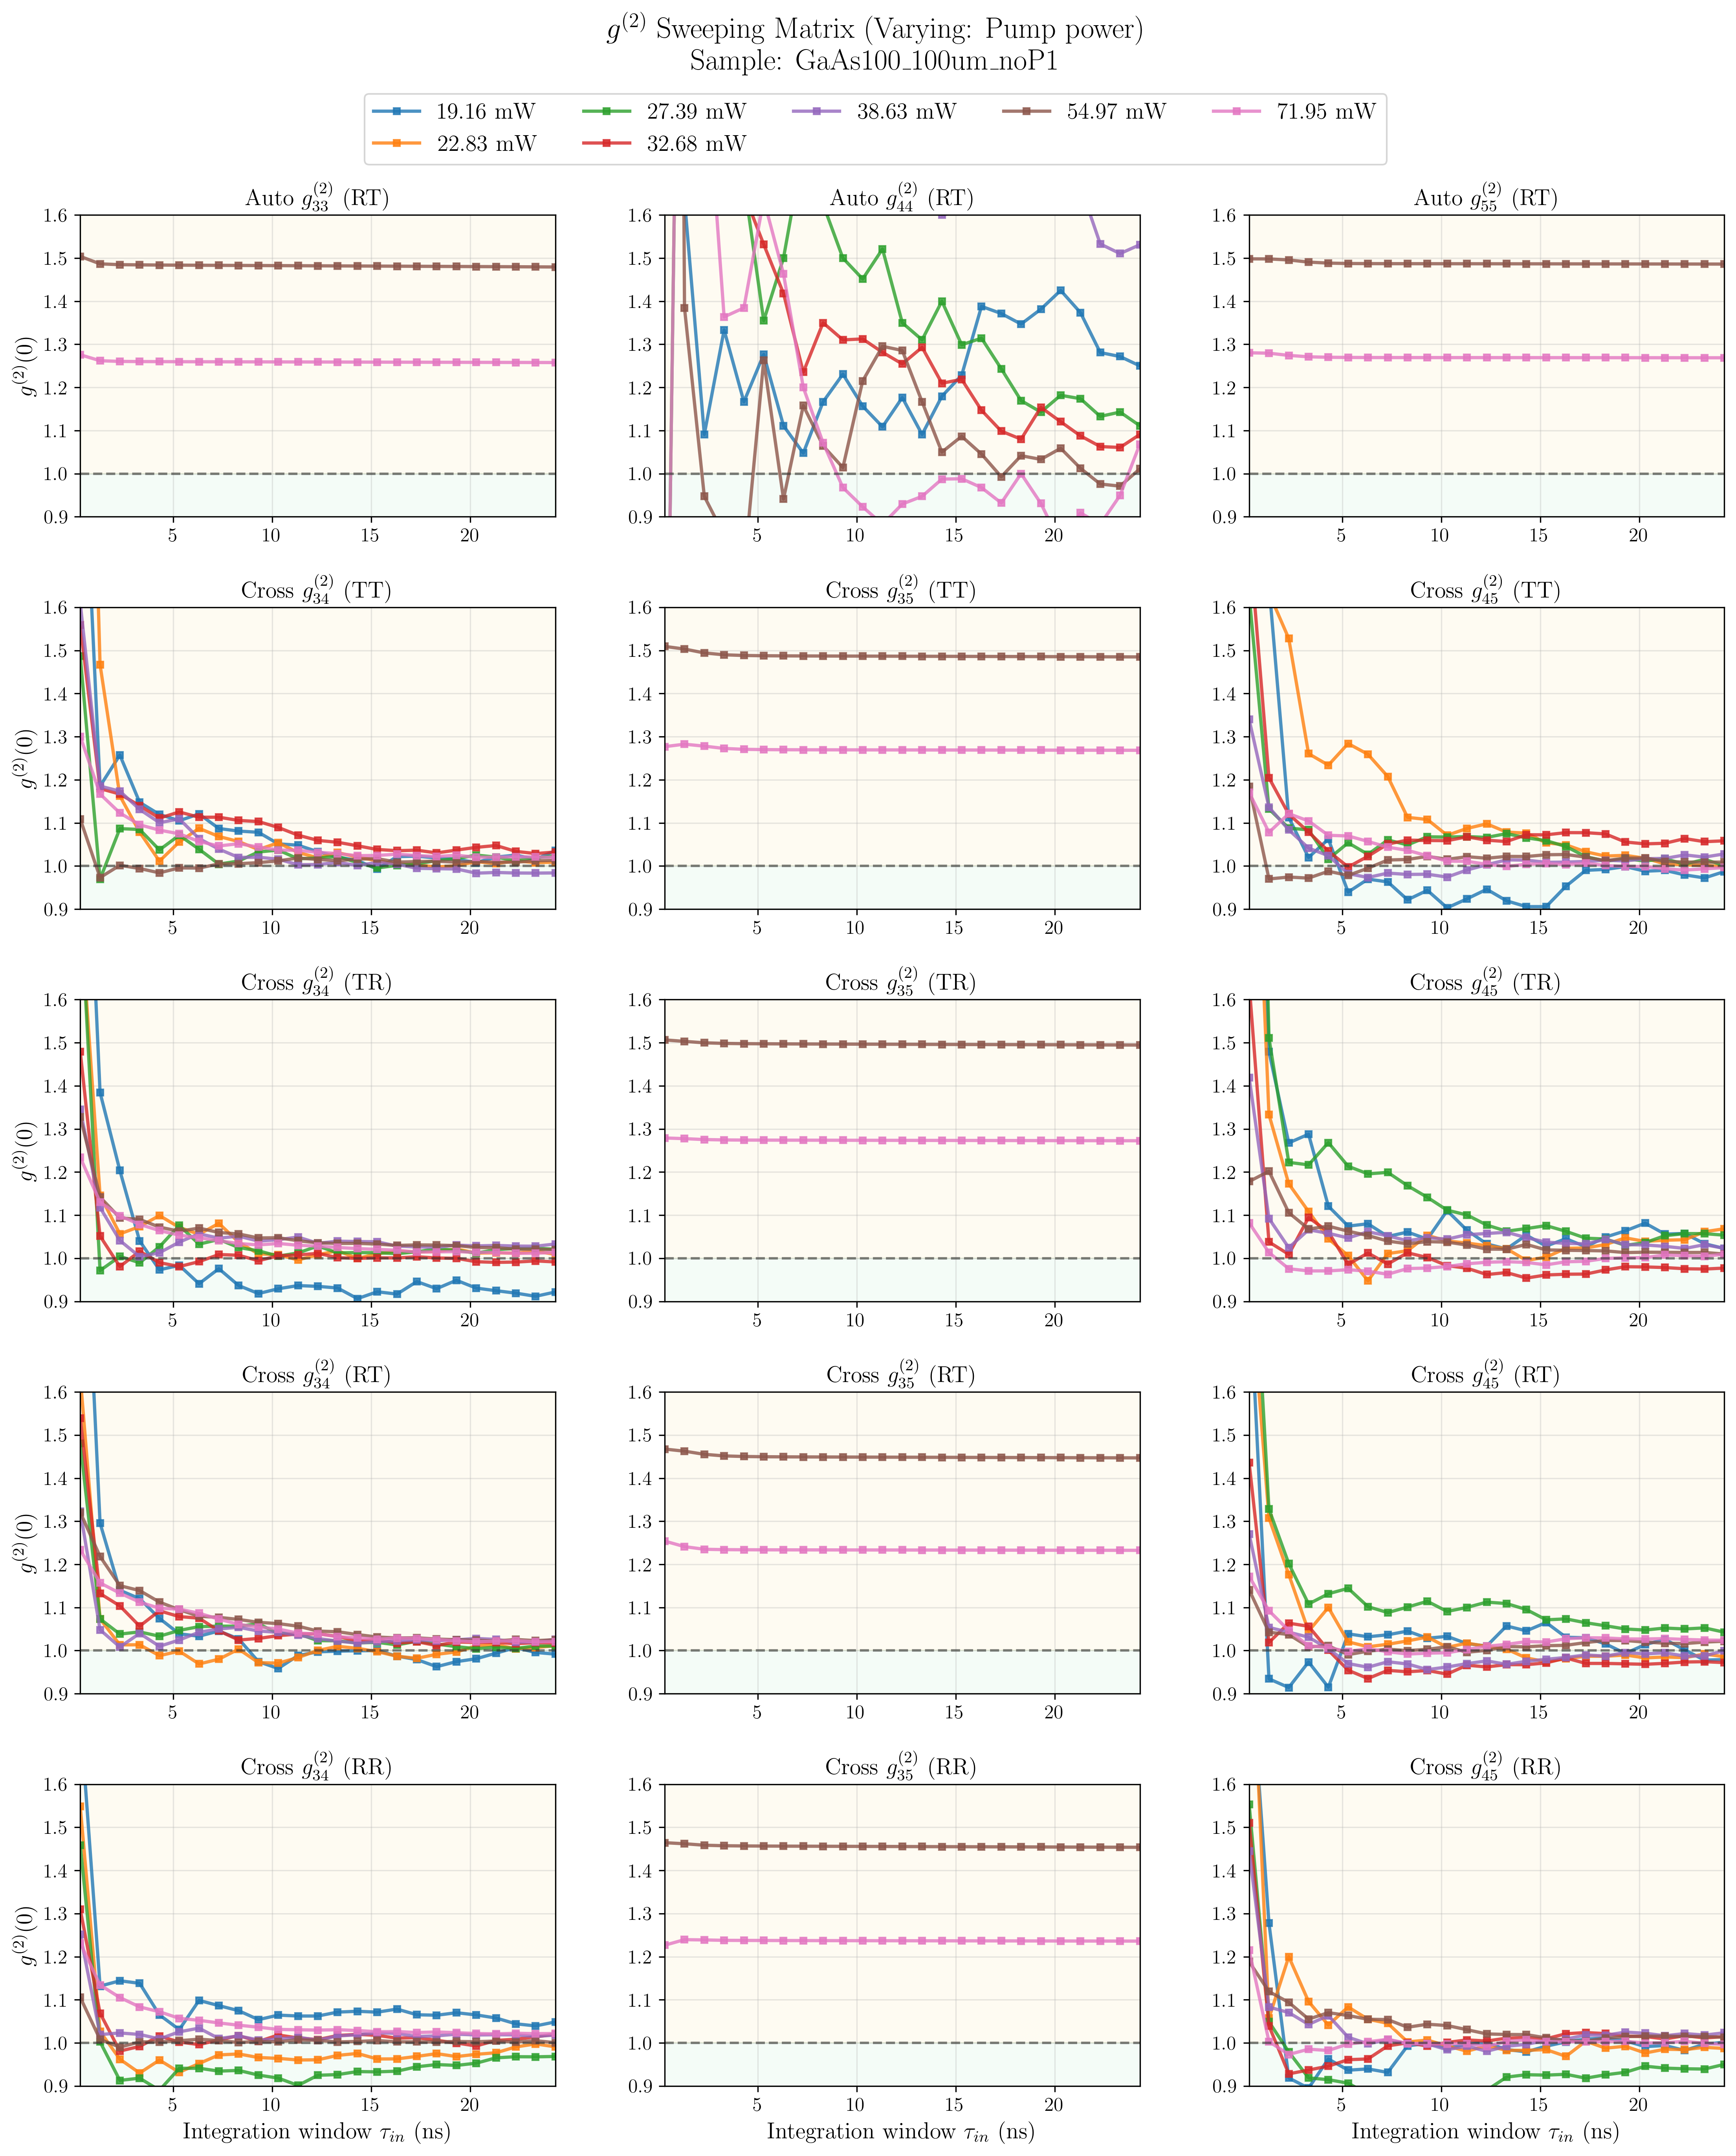

(<Figure size 5400x6000 with 15 Axes>,
 array([[<Axes: title={'center': 'Auto $g^{(2)}_{33}$ (RT)'}, ylabel='$g^{(2)}(0)$'>,
         <Axes: title={'center': 'Auto $g^{(2)}_{44}$ (RT)'}>,
         <Axes: title={'center': 'Auto $g^{(2)}_{55}$ (RT)'}>],
        [<Axes: title={'center': 'Cross $g^{(2)}_{34}$ (TT)'}, ylabel='$g^{(2)}(0)$'>,
         <Axes: title={'center': 'Cross $g^{(2)}_{35}$ (TT)'}>,
         <Axes: title={'center': 'Cross $g^{(2)}_{45}$ (TT)'}>],
        [<Axes: title={'center': 'Cross $g^{(2)}_{34}$ (TR)'}, ylabel='$g^{(2)}(0)$'>,
         <Axes: title={'center': 'Cross $g^{(2)}_{35}$ (TR)'}>,
         <Axes: title={'center': 'Cross $g^{(2)}_{45}$ (TR)'}>],
        [<Axes: title={'center': 'Cross $g^{(2)}_{34}$ (RT)'}, ylabel='$g^{(2)}(0)$'>,
         <Axes: title={'center': 'Cross $g^{(2)}_{35}$ (RT)'}>,
         <Axes: title={'center': 'Cross $g^{(2)}_{45}$ (RT)'}>],
        [<Axes: title={'center': 'Cross $g^{(2)}_{34}$ (RR)'}, xlabel='Integration window $\\tau_{in

In [3]:
comp = GridVisualizer(runs, comparison_variable="Pump power")
ref = runs[0]

comp.plot_coherence(xlim=120, integration_window_ns=5.0)
comp.plot_g2(methods=['delay'], tau_min=0.3, tau_max=25, step=1.0)

In [4]:
TAU_INT = 4

## 3. Build the analyzer & numeric table

`PowerScanAnalyzer` assembles, for every power: the harmonic intensities $\langle I_n\rangle$,
the local exponents $K(n)$, the auto/cross $g^{(2)}(0)$, and the rescaled collapse
$(g^{(2)}_n-1)/K^2(n)$.

In [5]:
psa = PowerScanAnalyzer(runs, harmonics=(3, 4, 5), tau_in_ns=TAU_INT, g2_method='delay')
psa.summary_table()

   P(mW)         I3         I4         I5     K3     K4     K5   g2_33   g2_44   g2_55  (g-1)/K2_3  (g-1)/K2_4  (g-1)/K2_5
--------------------------------------------------------------------------------------------------------------------------
    19.2  1.122e+05       5324  5.441e+04   2.96   0.00   3.71   2.658   1.200   3.580      0.1894   9825.9727      0.1877
    22.8  1.884e+05       5328  1.042e+05   2.86   0.00   3.45   2.465   4.909   3.141      0.1786 357463.7098      0.1795
    27.4  3.117e+05       5330  1.863e+05   2.70   0.00   3.01   2.257   1.750   2.677      0.1720 899983.7582      0.1848
    32.7  4.972e+05       5330  3.076e+05   2.60   0.00   2.71   2.042   1.784   2.285      0.1542 837281.0085      0.1746
    38.6  7.627e+05       5332  4.746e+05   2.49   0.02   2.47   1.841   2.000   1.958      0.1354   2125.4791      0.1568
    55.0  1.748e+06       5452  1.037e+06   2.25   0.03   2.04   1.484   0.774   1.489      0.0954   -223.4661      0.1176
    72.0  3.141e

## 4. Intensity scaling — verification (3)

$\log\langle I_n\rangle$ vs $\log I_0$. The straight low-power part has slope $K(n)\approx n$
(dashed = ideal slope $n$); the bend at high power is saturation. The companion plot shows the
**local exponent** $K(n)$ that quantifies the bend (dotted = ideal order $n$).

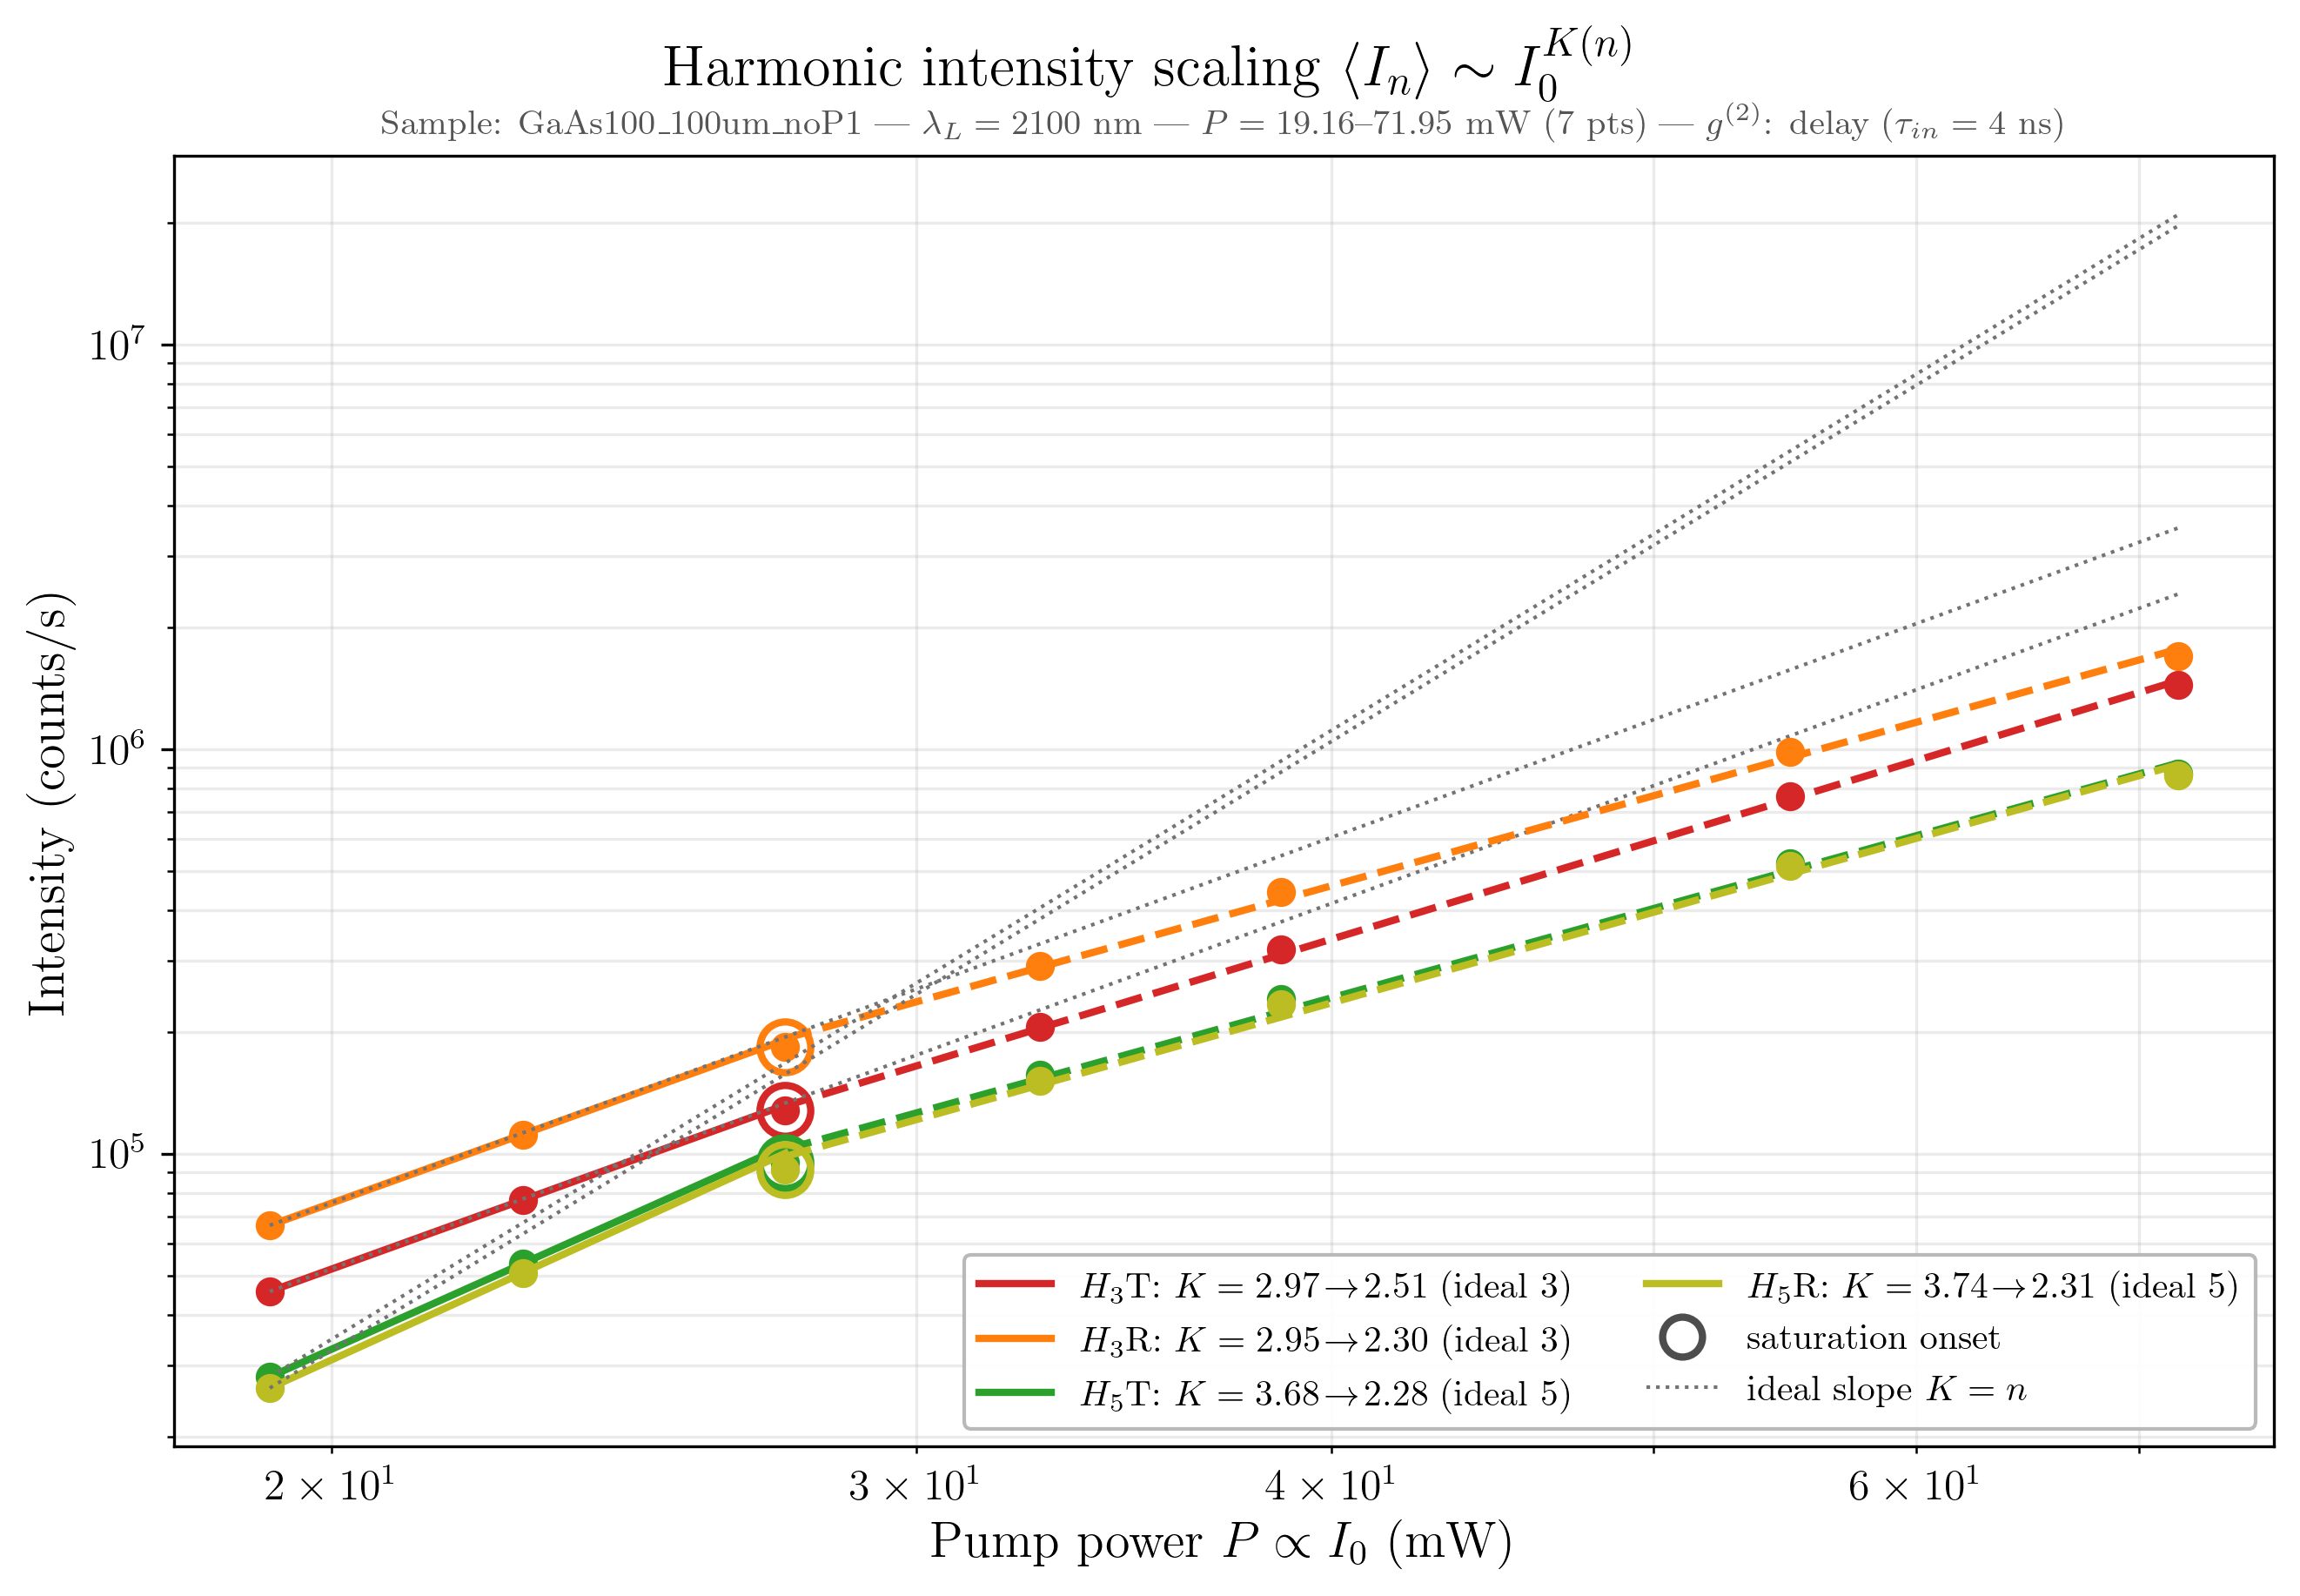

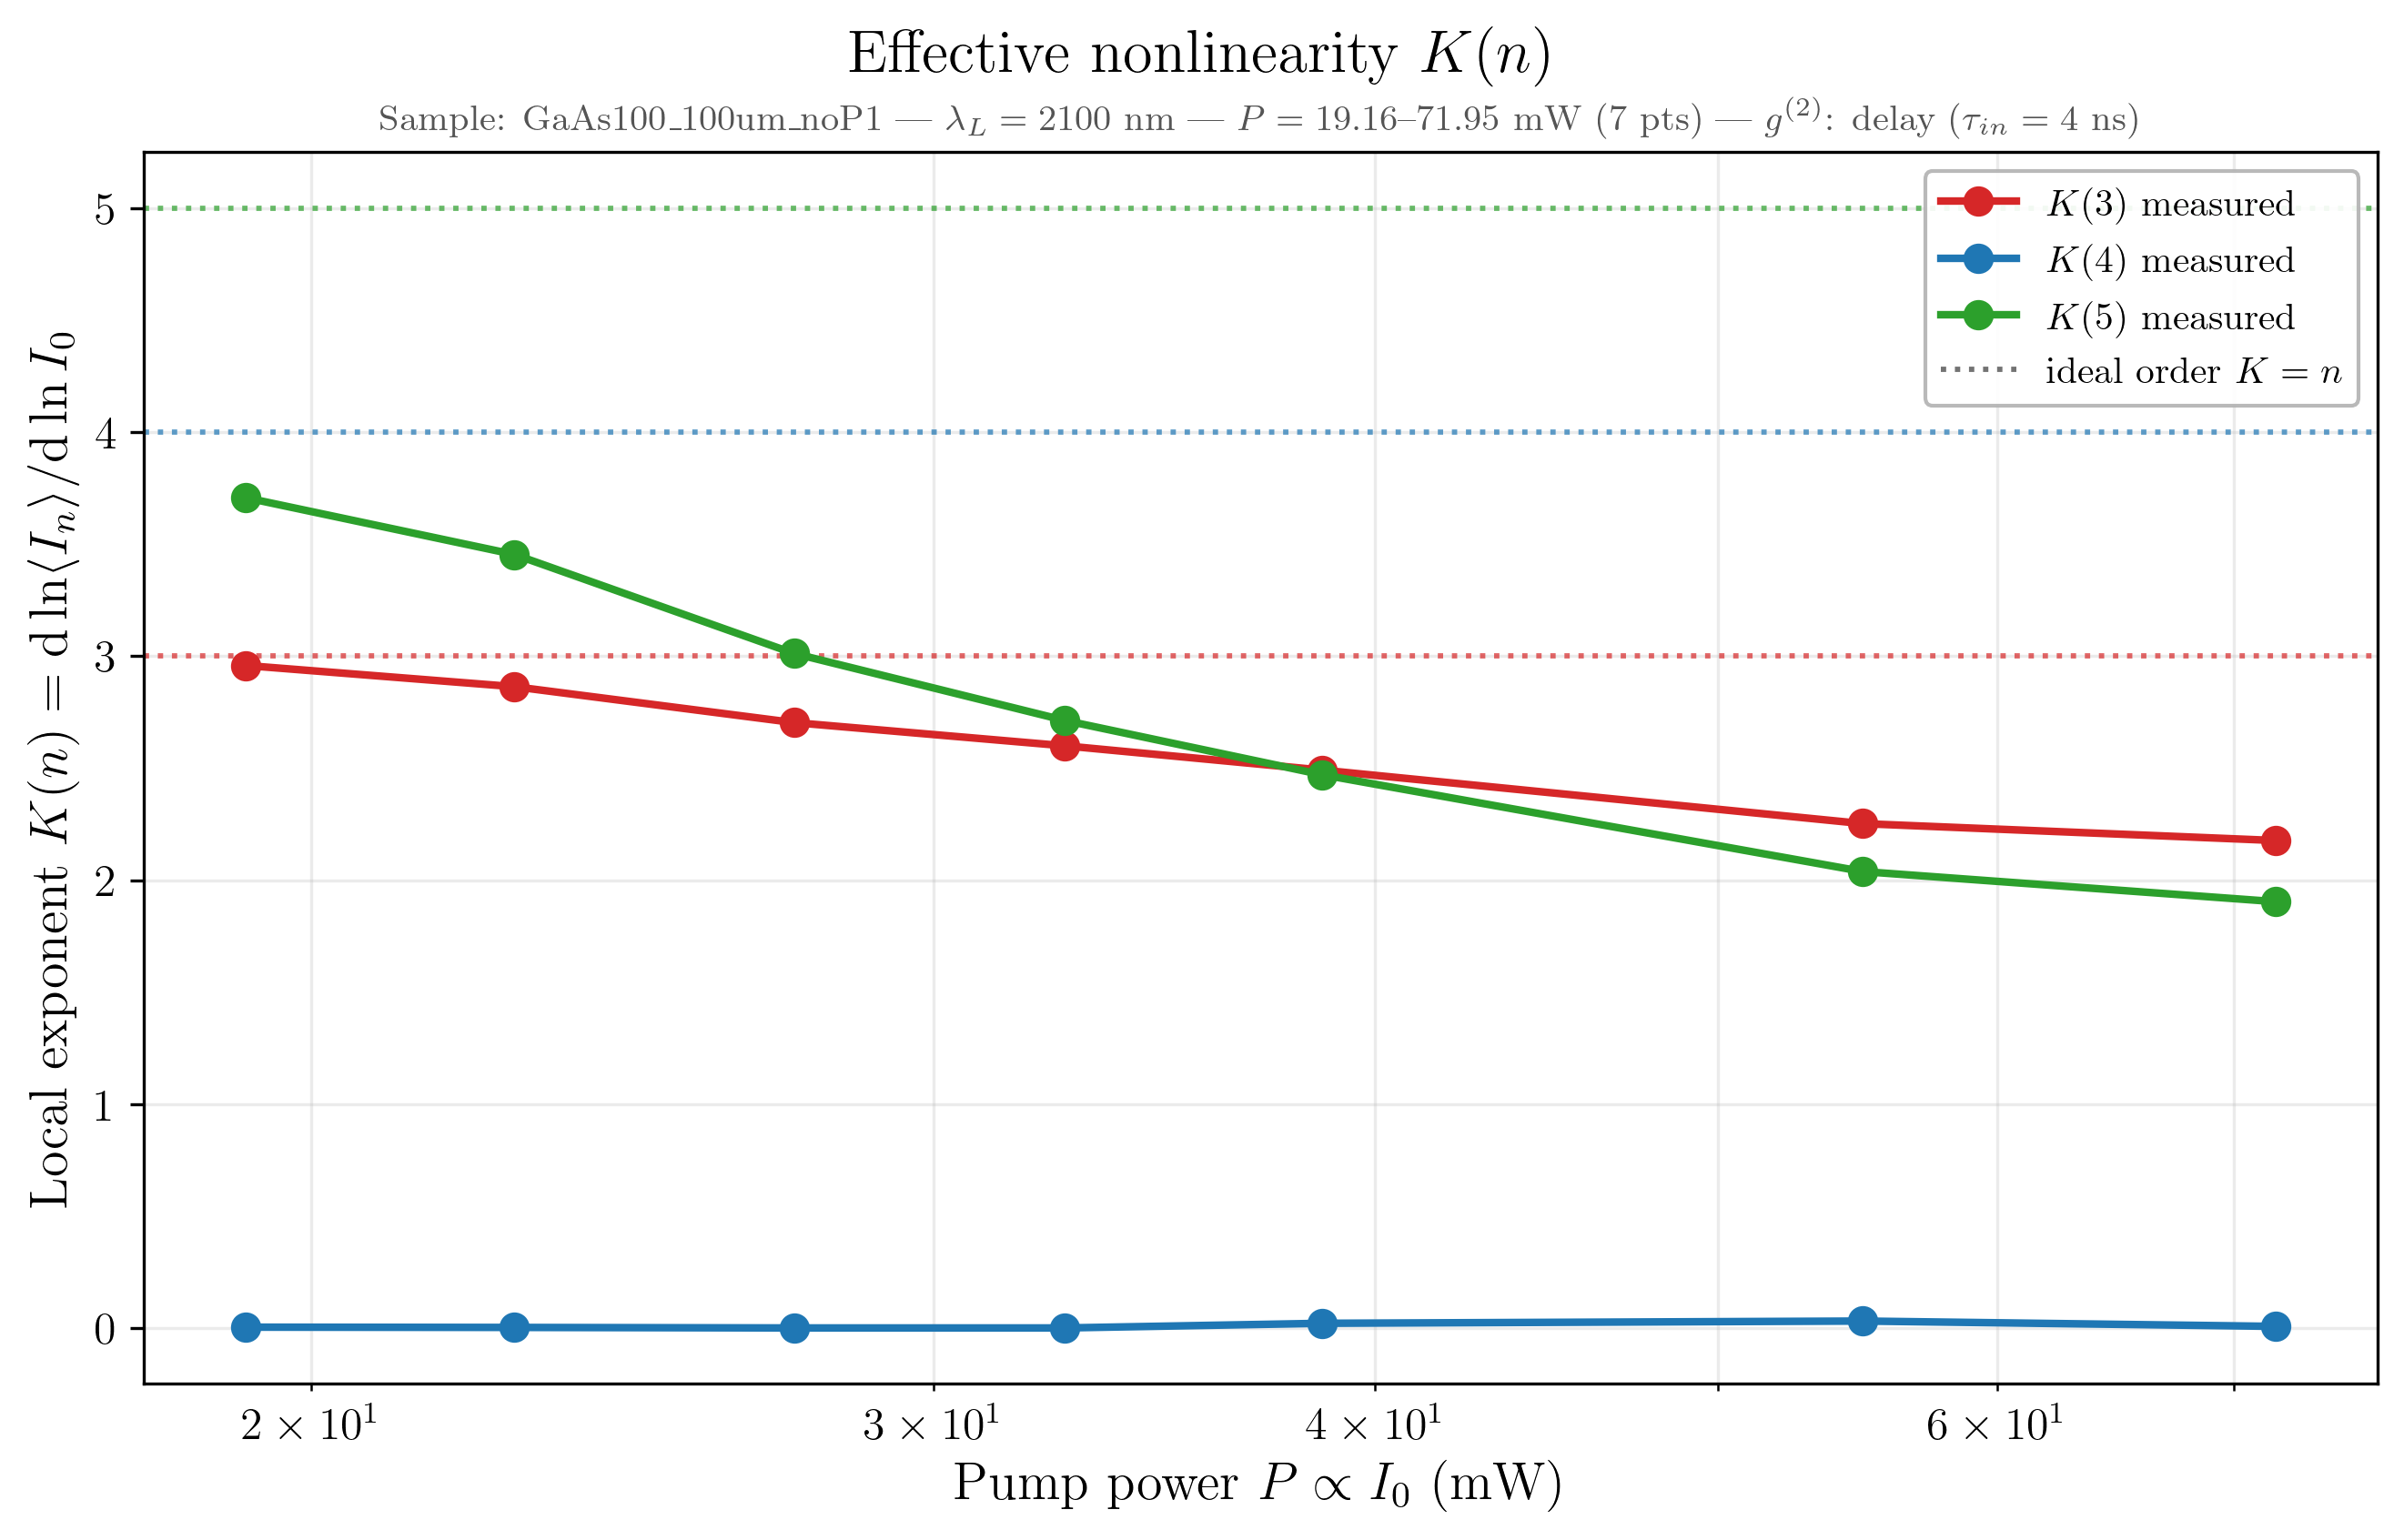

(<Figure size 2700x1800 with 1 Axes>,
 <Axes: title={'center': 'Sample: GaAs100_100um_noP1  |  $\\lambda_L = 2100$ nm  |  $P = 19.16$--$71.95$ mW (7 pts)  |  $g^{(2)}$: delay ($\\tau_{in} = 4$ ns)'}, xlabel='Pump power $P \\propto I_0$ (mW)', ylabel='Local exponent $K(n) = \\mathrm{d}\\ln\\langle I_n\\rangle/\\mathrm{d}\\ln I_0$'>)

In [6]:
psa.plot_intensity_scaling(n_fit=1, harmonics=(3,5))
psa.plot_local_slope()

## 5. $g^{(2)}(0)$ vs pump power — verification (1)

A family of distinct curves. Auto-correlations $g^{(2)}_{nn}$ (solid) and the cross pairs
$g^{(2)}_{mn}$ (dashed). Higher harmonics (larger $K$) are more bunched.

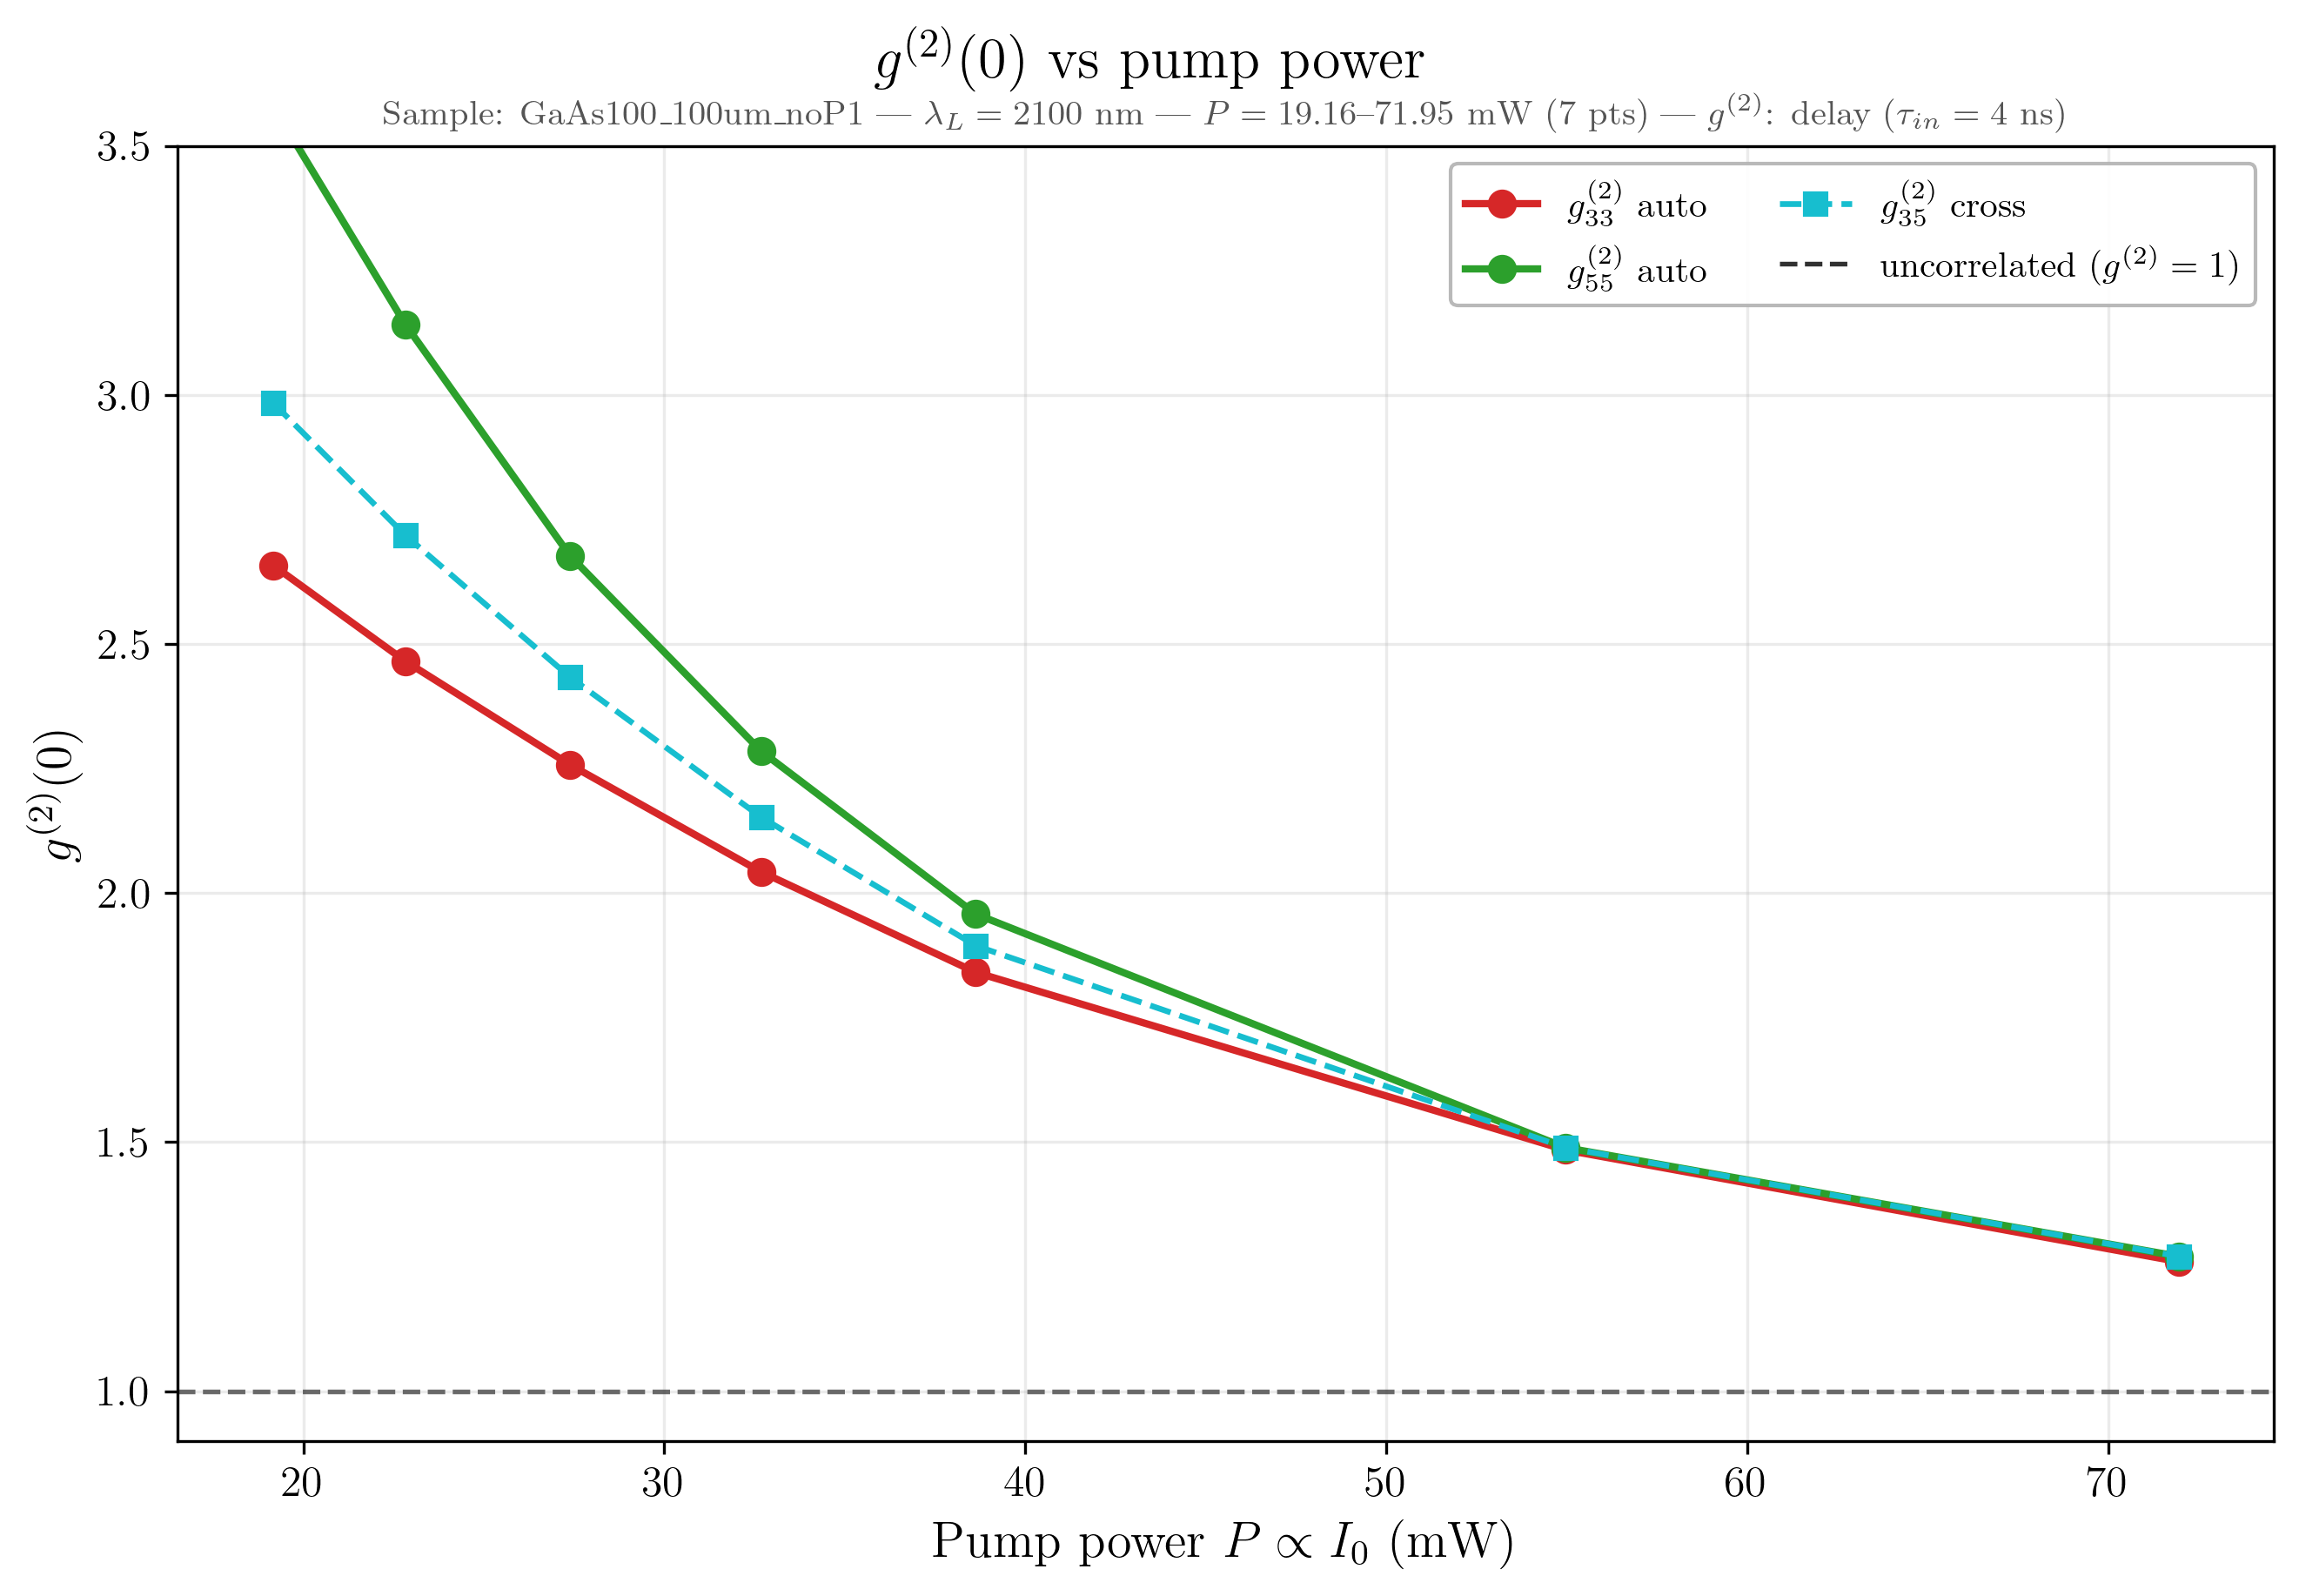

(<Figure size 2700x1950 with 1 Axes>,
 <Axes: title={'center': 'Sample: GaAs100_100um_noP1  |  $\\lambda_L = 2100$ nm  |  $P = 19.16$--$71.95$ mW (7 pts)  |  $g^{(2)}$: delay ($\\tau_{in} = 4$ ns)'}, xlabel='Pump power $P \\propto I_0$ (mW)', ylabel='$g^{(2)}(0)$'>)

In [7]:
psa.plot_g2_vs_power(ylim=(0.9, 3.5), harmonics=(3,5), include_cross=True)

## 6. The collapse — verification (2), the key test

Dividing by $K^2(n)$ (auto) or $K(m)K(n)$ (cross) should make **every** curve fall on the same
universal line $g^{(2)}_0-1=\sigma^2$. The black curve is the mean over all harmonics/pairs: our
**indirect measurement of the pump bunching** $\sigma^2$ (shaded = spread between harmonics).

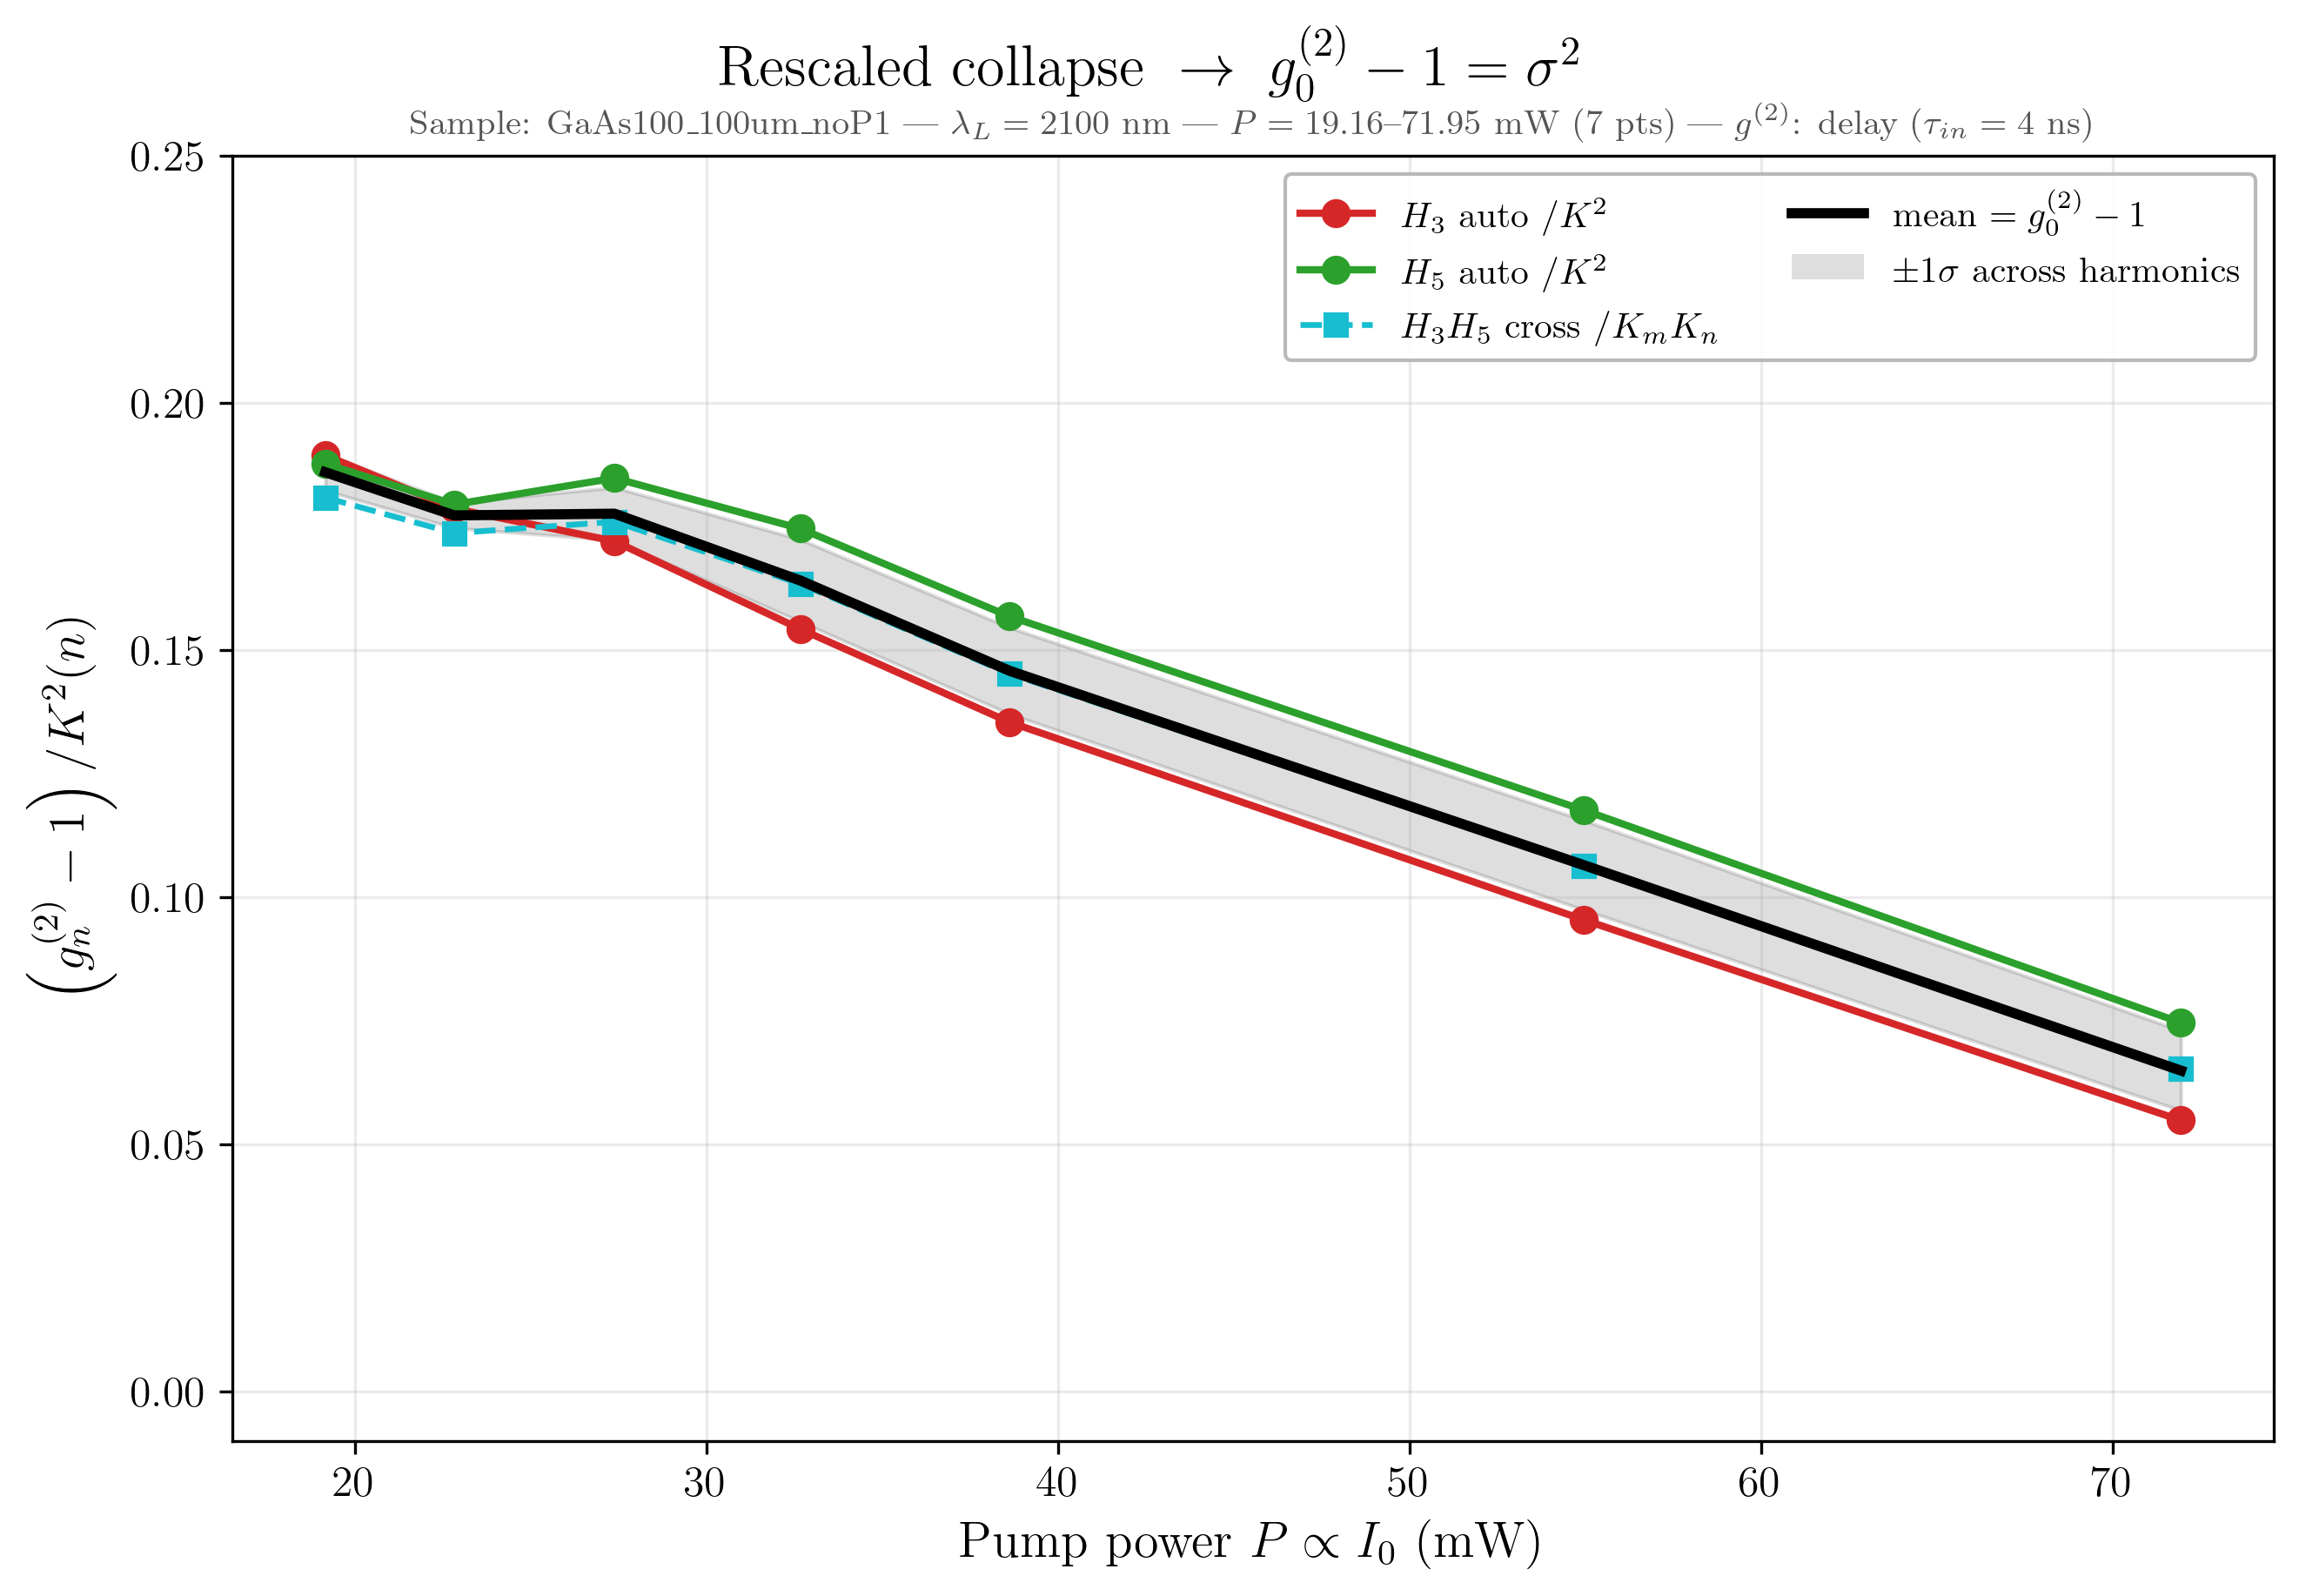

Inferred pump excess  g2_0 - 1 = sigma^2  (mean over harmonics, per power):
  P =   19.2 mW :  sigma^2 = 1640.1440  +/- 3660.8163
  P =   22.8 mW :  sigma^2 = 59582.1042  +/- 133216.7042
  P =   27.4 mW :  sigma^2 = 150003.9771  +/- 335401.1546
  P =   32.7 mW :  sigma^2 = 139558.5612  +/- 312030.9648
  P =   38.6 mW :  sigma^2 = 354.7819  +/- 791.8802
  P =   55.0 mW :  sigma^2 = -37.2369  +/- 83.2843
  P =   72.0 mW :  sigma^2 = 1331.9635  +/- 2973.7619

Scan-averaged sigma^2 = 50347.7564  ->  g2_0 ~ 50348.7564


In [8]:
psa.plot_g2_collapse(slope='local', harmonics=(3,5), include_cross=True, ylim=(-0.01, 0.25))

mean, std = psa.inferred_g2_0()
print("Inferred pump excess  g2_0 - 1 = sigma^2  (mean over harmonics, per power):")
for P, m, s in zip(psa.I0, mean, std):
    print(f"  P = {P:6.1f} mW :  sigma^2 = {m:.4f}  +/- {s:.4f}")
print(f"\nScan-averaged sigma^2 = {np.nanmean(mean):.4f}  ->  g2_0 ~ {1+np.nanmean(mean):.4f}")

## 7. Full dashboard

The four panels together: $g^{(2)}$ vs power, the rescaled collapse, the intensity scaling and
the local exponent $K(n)$ — the complete picture of the model on one figure.

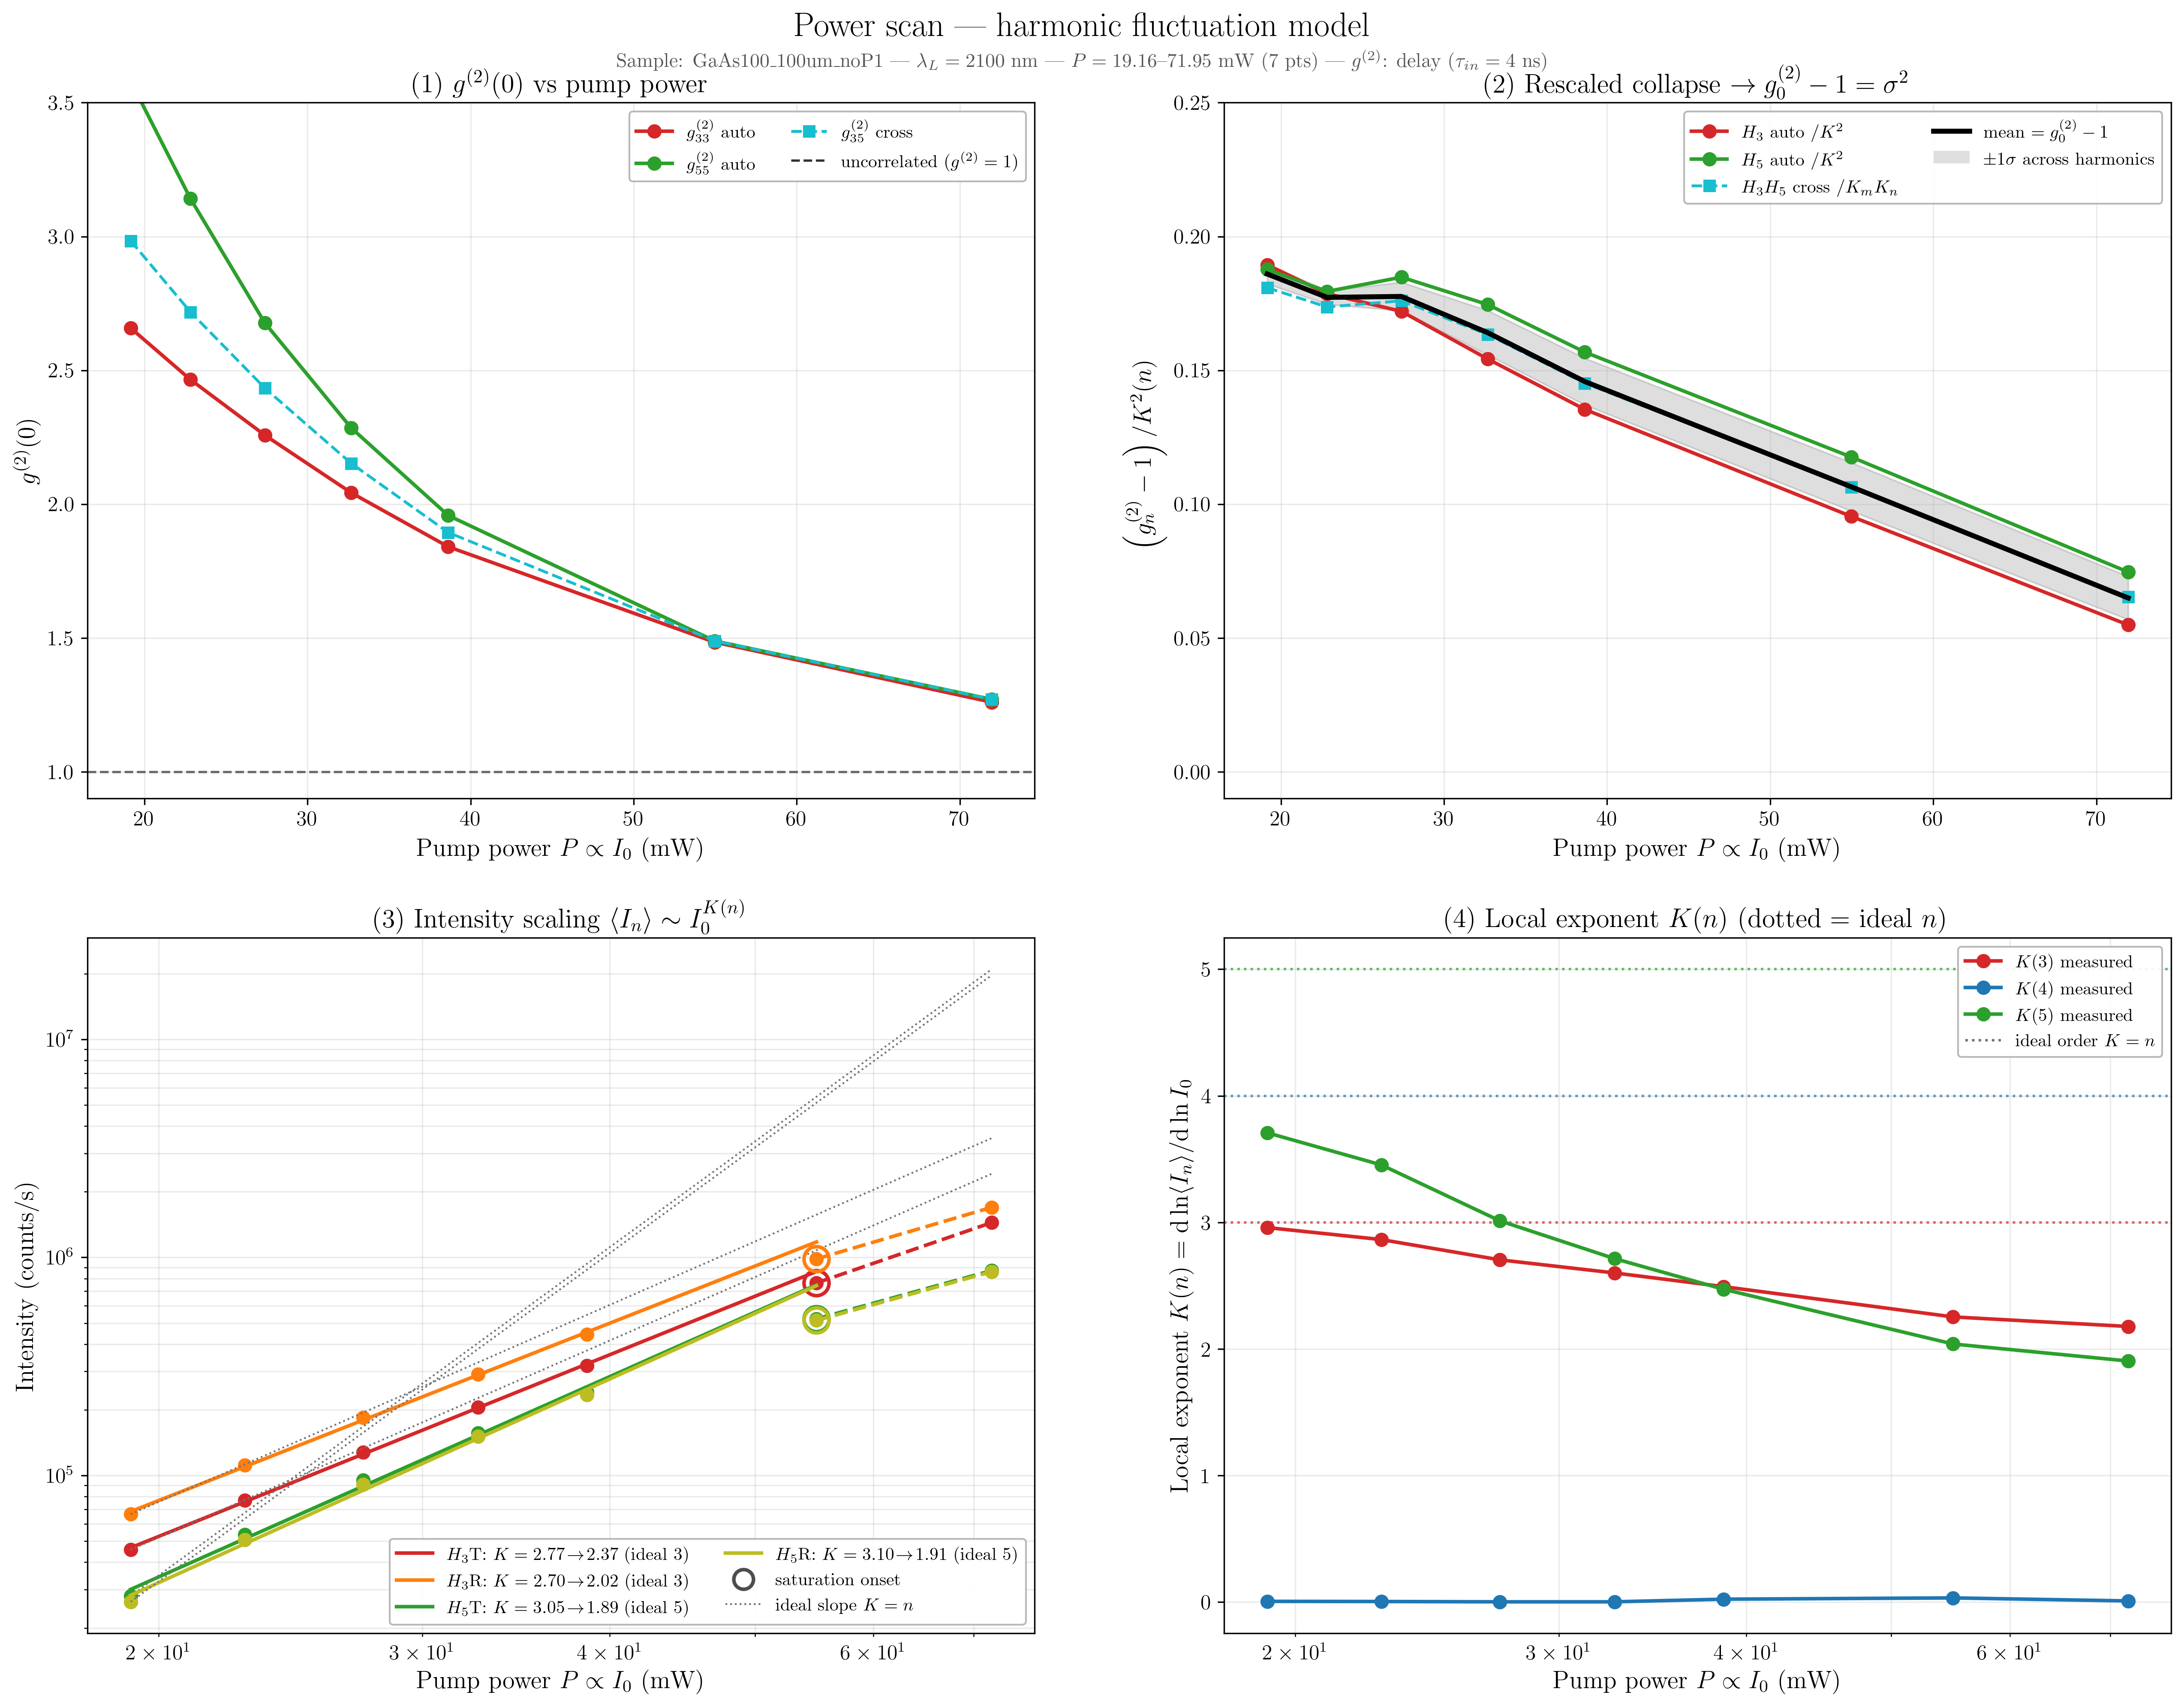

(<Figure size 5400x4200 with 4 Axes>,
 array([[<Axes: title={'center': '(1) $g^{(2)}(0)$ vs pump power'}, xlabel='Pump power $P \\propto I_0$ (mW)', ylabel='$g^{(2)}(0)$'>,
         <Axes: title={'center': '(2) Rescaled collapse $\\to g^{(2)}_0 - 1 = \\sigma^2$'}, xlabel='Pump power $P \\propto I_0$ (mW)', ylabel='$\\left(g^{(2)}_n - 1\\right)/K^2(n)$'>],
        [<Axes: title={'center': '(3) Intensity scaling $\\langle I_n\\rangle \\sim I_0^{K(n)}$'}, xlabel='Pump power $P \\propto I_0$ (mW)', ylabel='Intensity (counts/s)'>,
         <Axes: title={'center': '(4) Local exponent $K(n)$  (dotted = ideal $n$)'}, xlabel='Pump power $P \\propto I_0$ (mW)', ylabel='Local exponent $K(n) = \\mathrm{d}\\ln\\langle I_n\\rangle/\\mathrm{d}\\ln I_0$'>]],
       dtype=object))

In [9]:
psa.plot_overview(slope='local', n_fit=5, harmonics=(3,5), g2_ylim=(0.9, 3.5), collapse_ylim=(-0.01, 0.25))

## 8. (optional) Per-pair matrices vs power

`GridVisualizer` plots the full $5\times3$ $g^{(2)}$ matrix and $4\times3$ Cauchy–Schwarz $R$
matrix, every panel as a function of power at the chosen window — handy to scan every channel
pair at once.

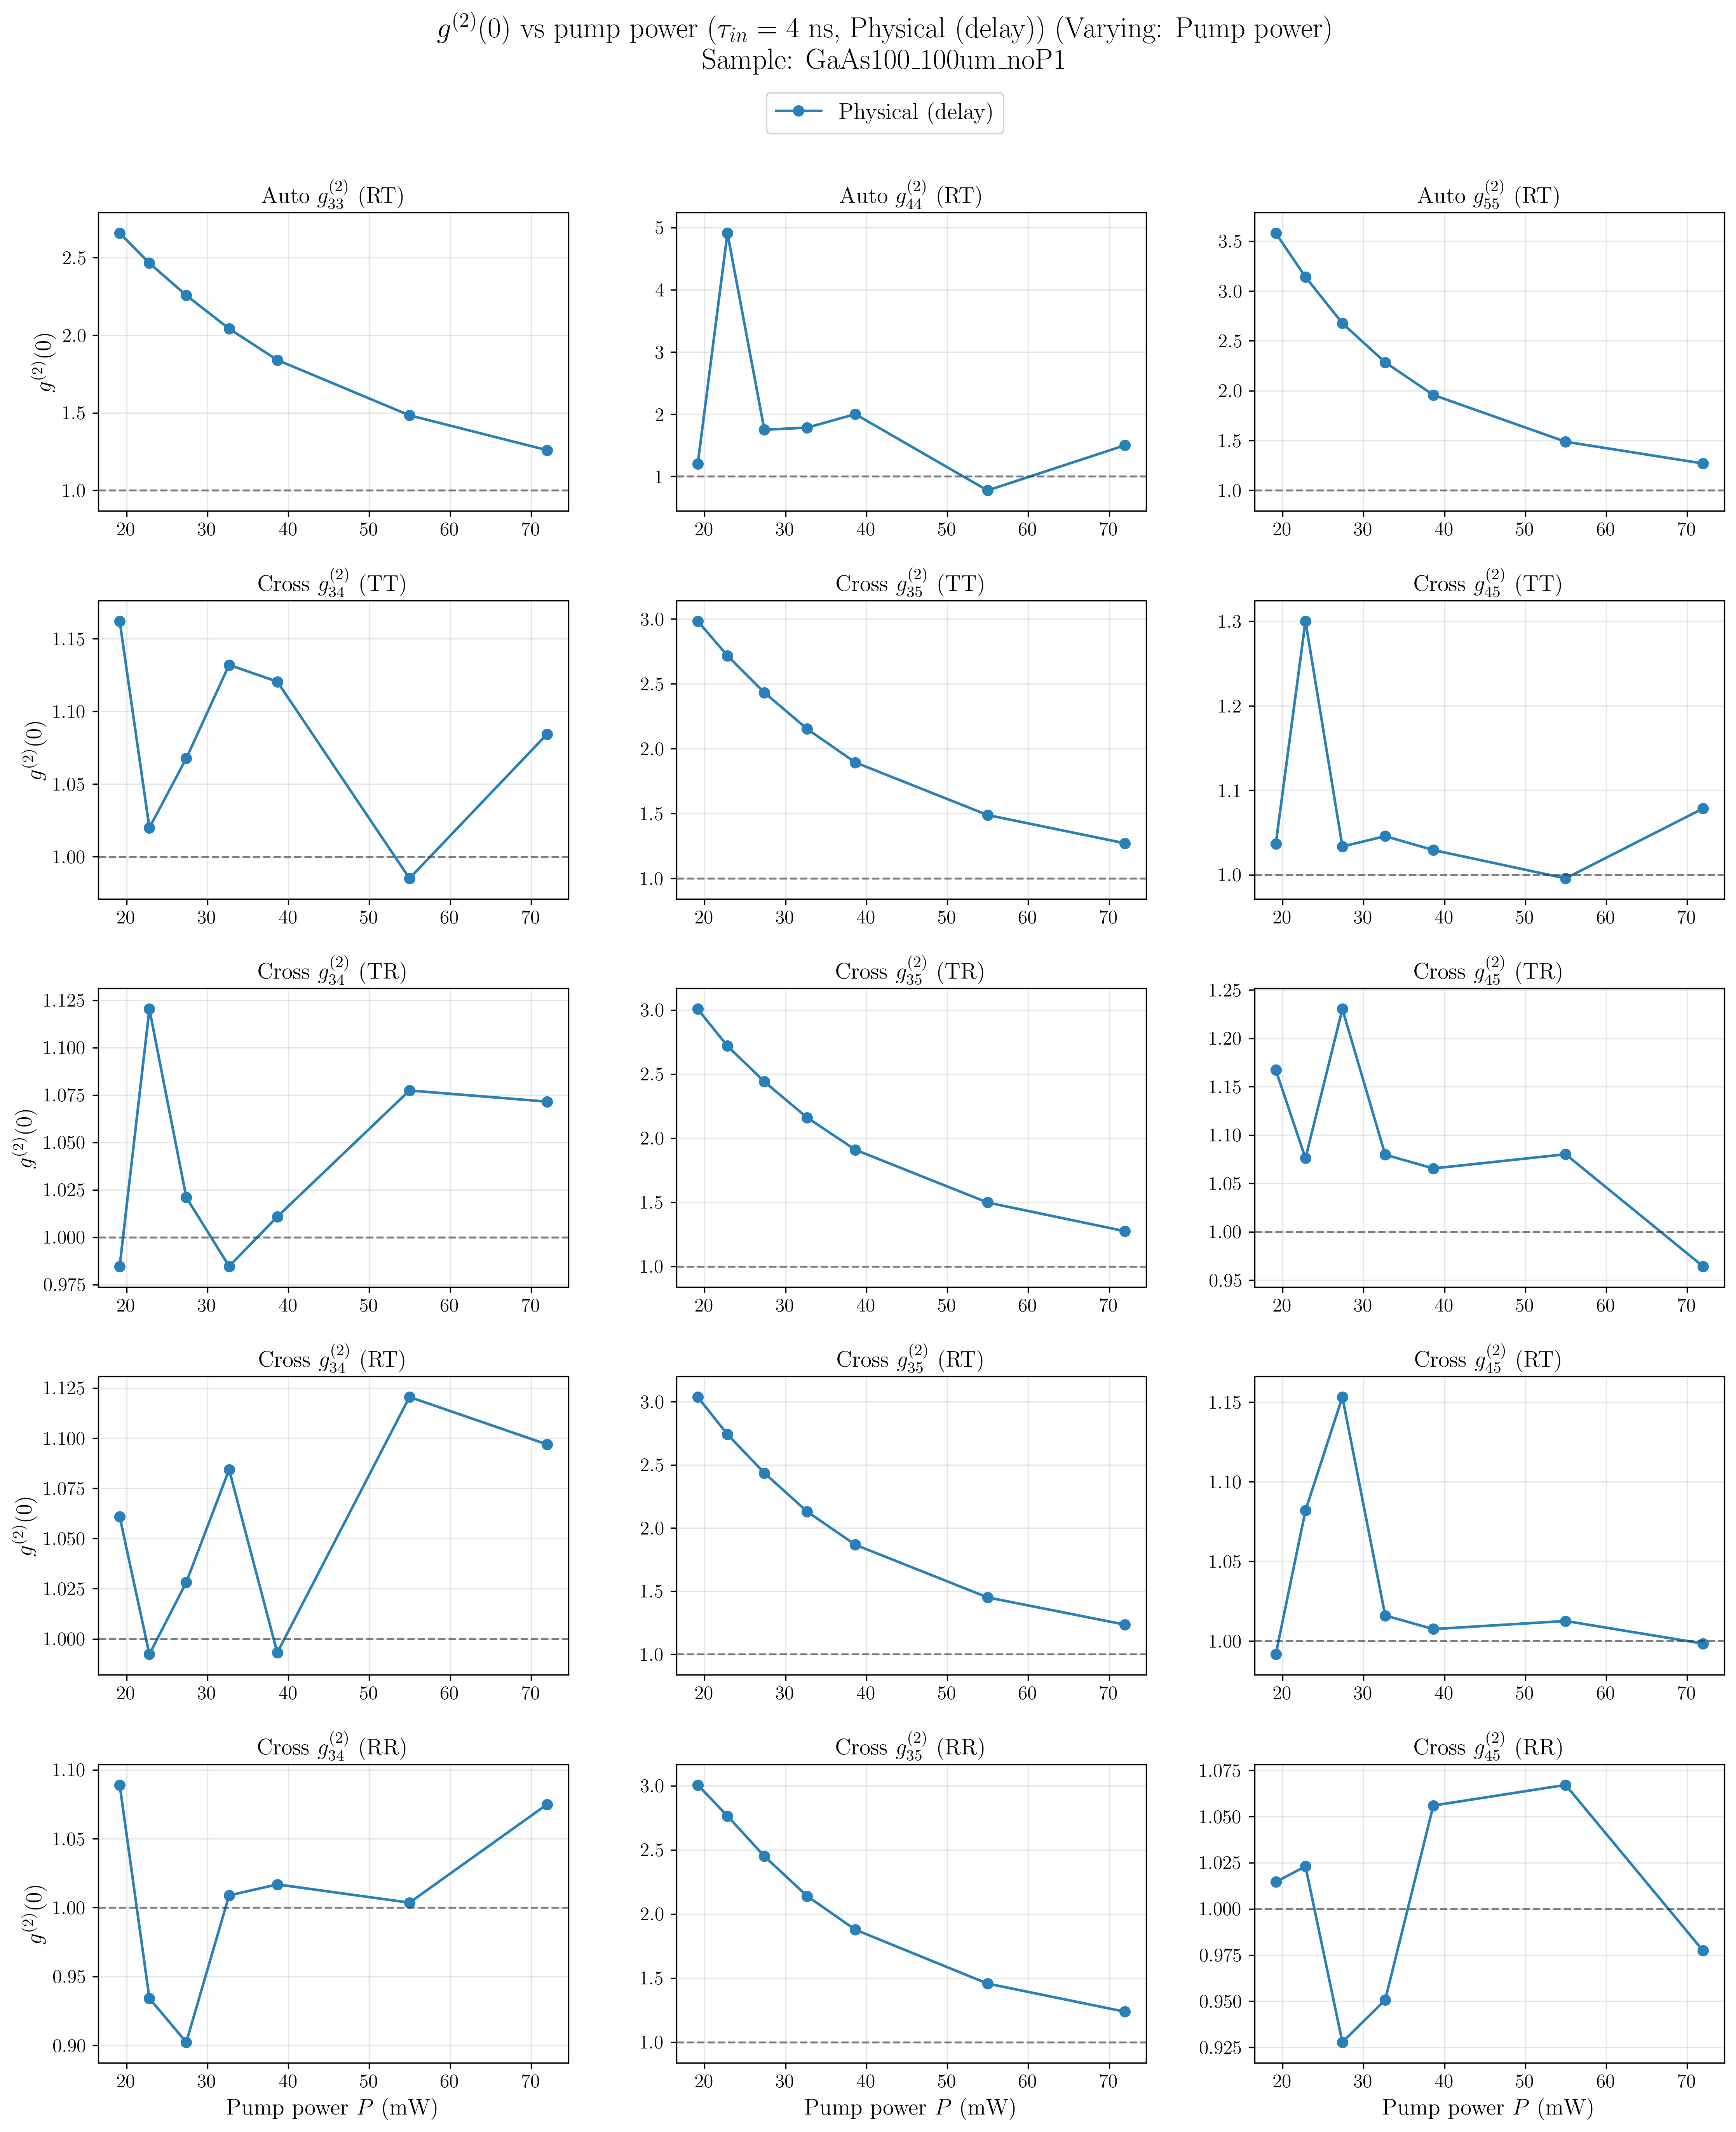

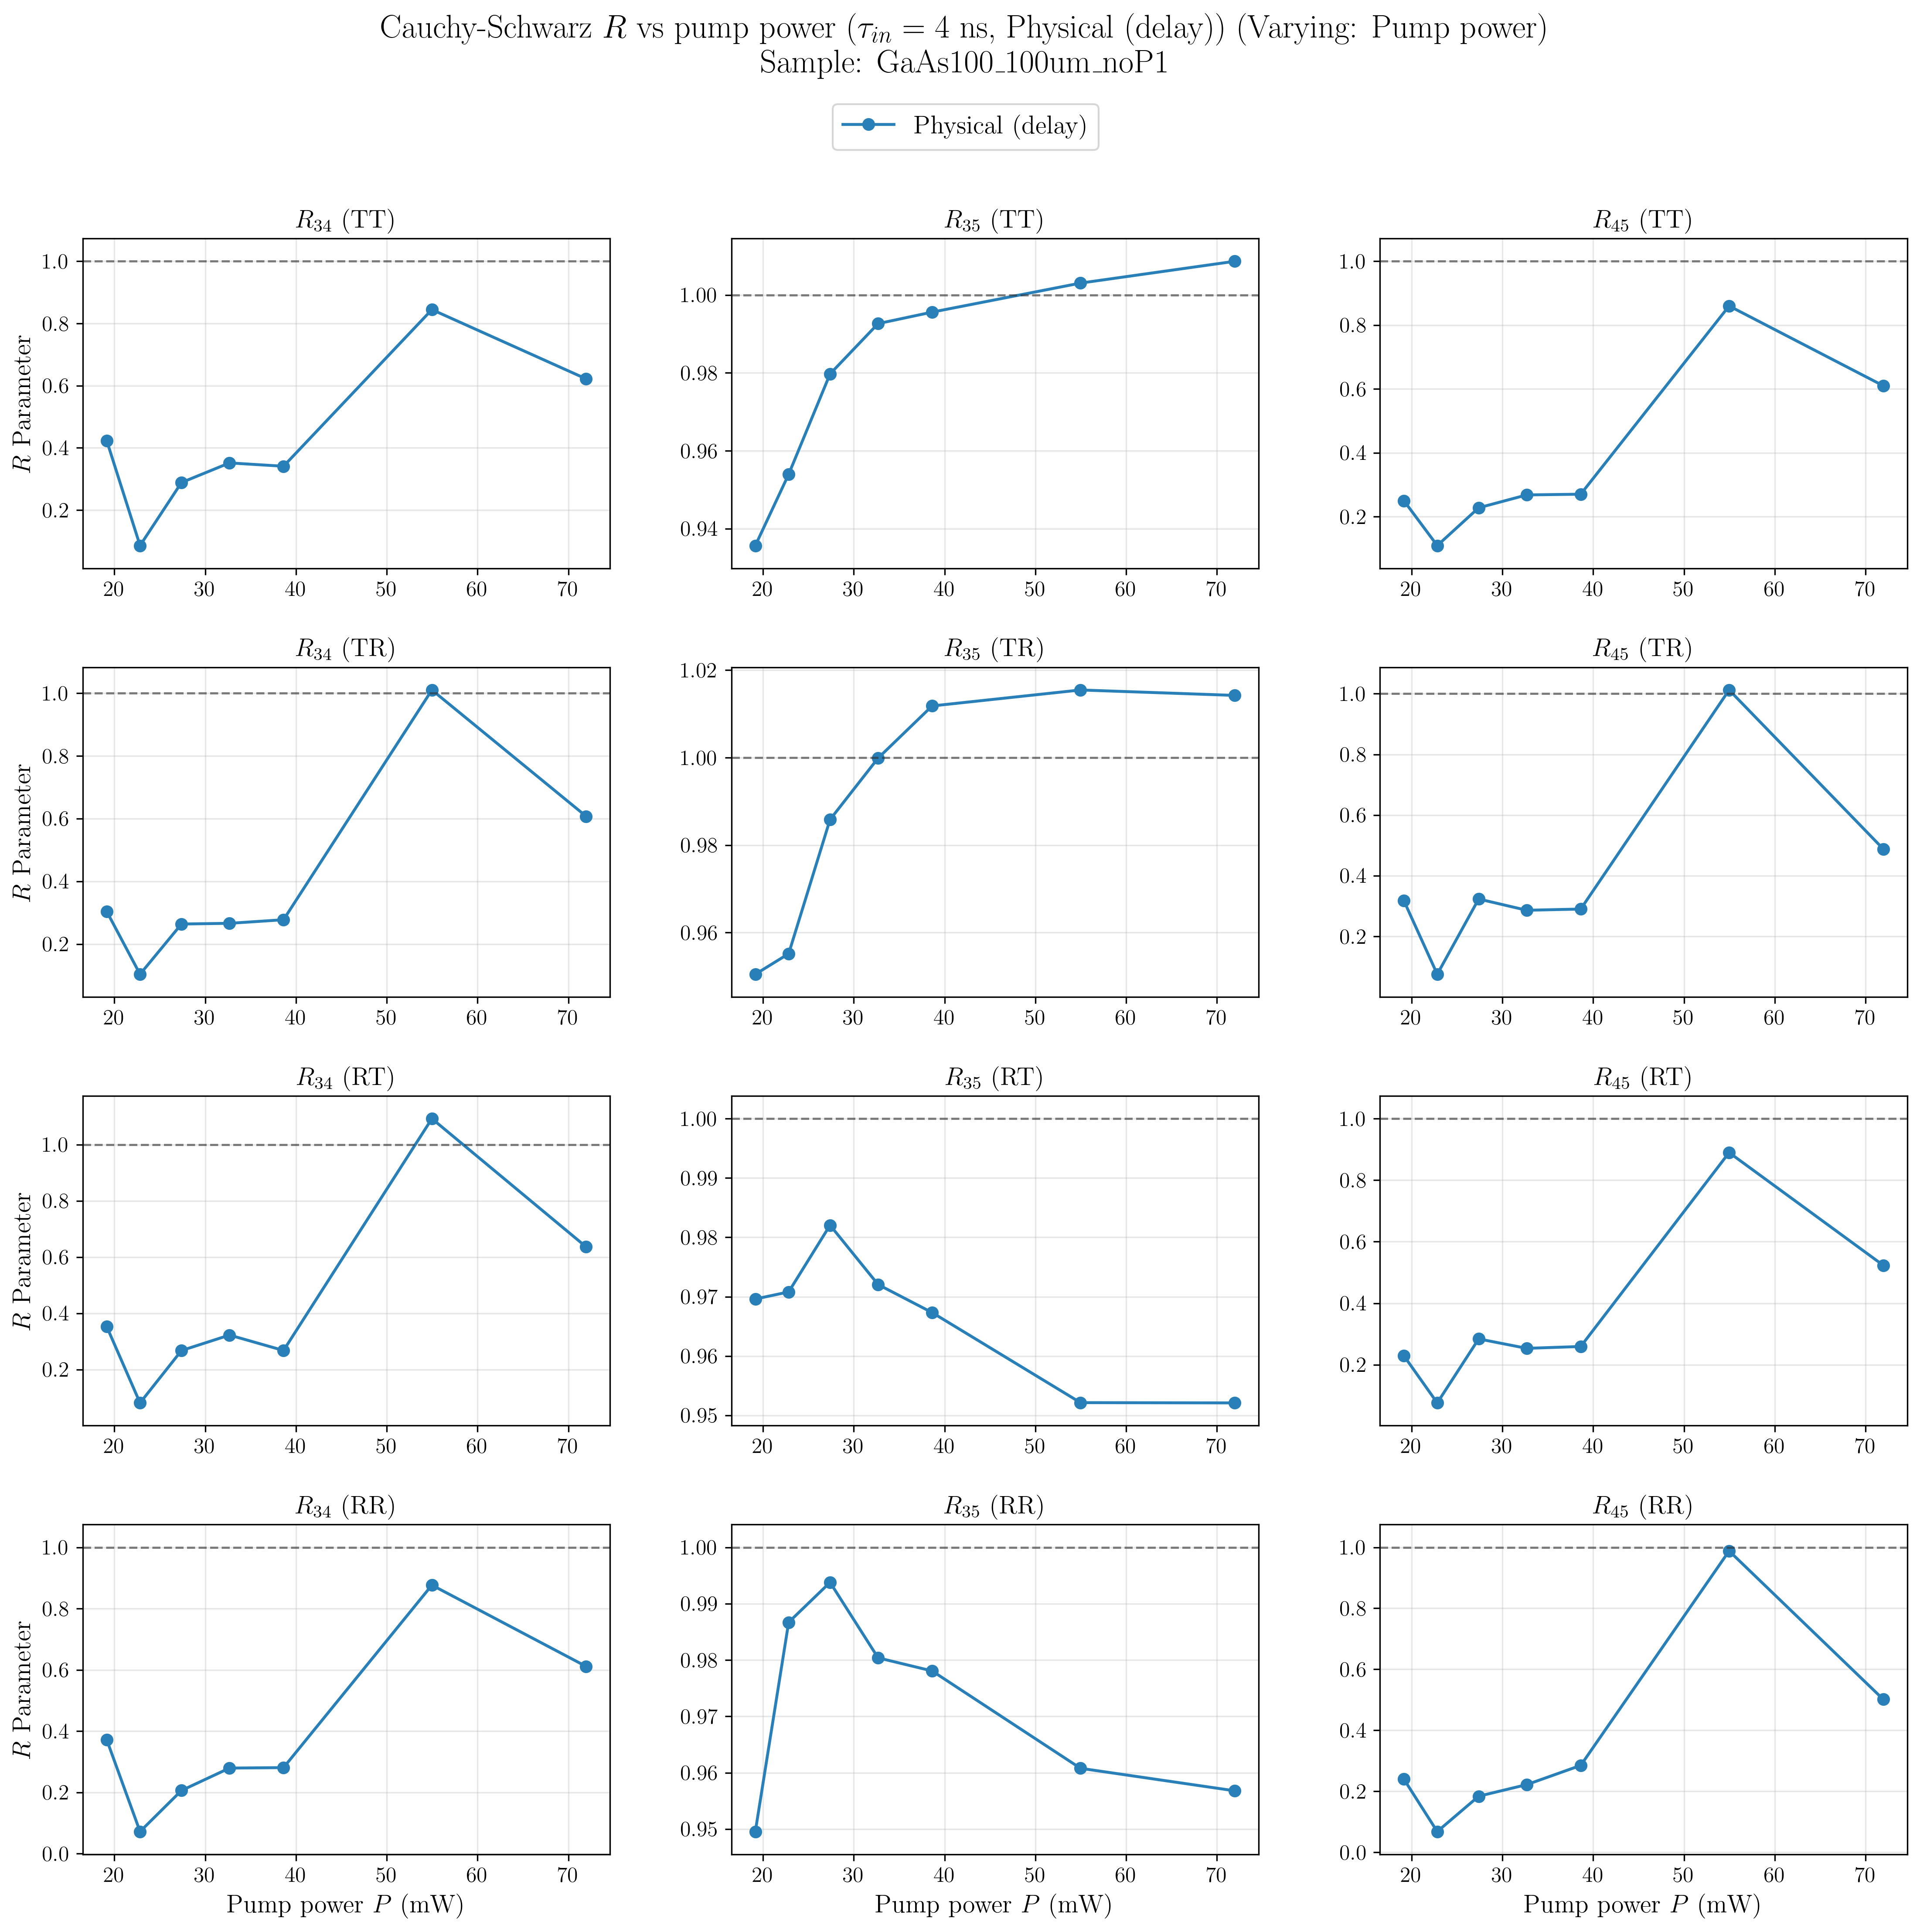

(<Figure size 5400x4800 with 12 Axes>,
 array([[<Axes: title={'center': '$R_{34}$ (TT)'}, ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (TT)'}>,
         <Axes: title={'center': '$R_{45}$ (TT)'}>],
        [<Axes: title={'center': '$R_{34}$ (TR)'}, ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (TR)'}>,
         <Axes: title={'center': '$R_{45}$ (TR)'}>],
        [<Axes: title={'center': '$R_{34}$ (RT)'}, ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (RT)'}>,
         <Axes: title={'center': '$R_{45}$ (RT)'}>],
        [<Axes: title={'center': '$R_{34}$ (RR)'}, xlabel='Pump power $P$ (mW)', ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (RR)'}, xlabel='Pump power $P$ (mW)'>,
         <Axes: title={'center': '$R_{45}$ (RR)'}, xlabel='Pump power $P$ (mW)'>]],
       dtype=object))

In [10]:
comp.plot_power_scan_g2(tau_in_ns=TAU_INT, method='delay')
comp.plot_power_scan_R(tau_in_ns=TAU_INT, method='delay')

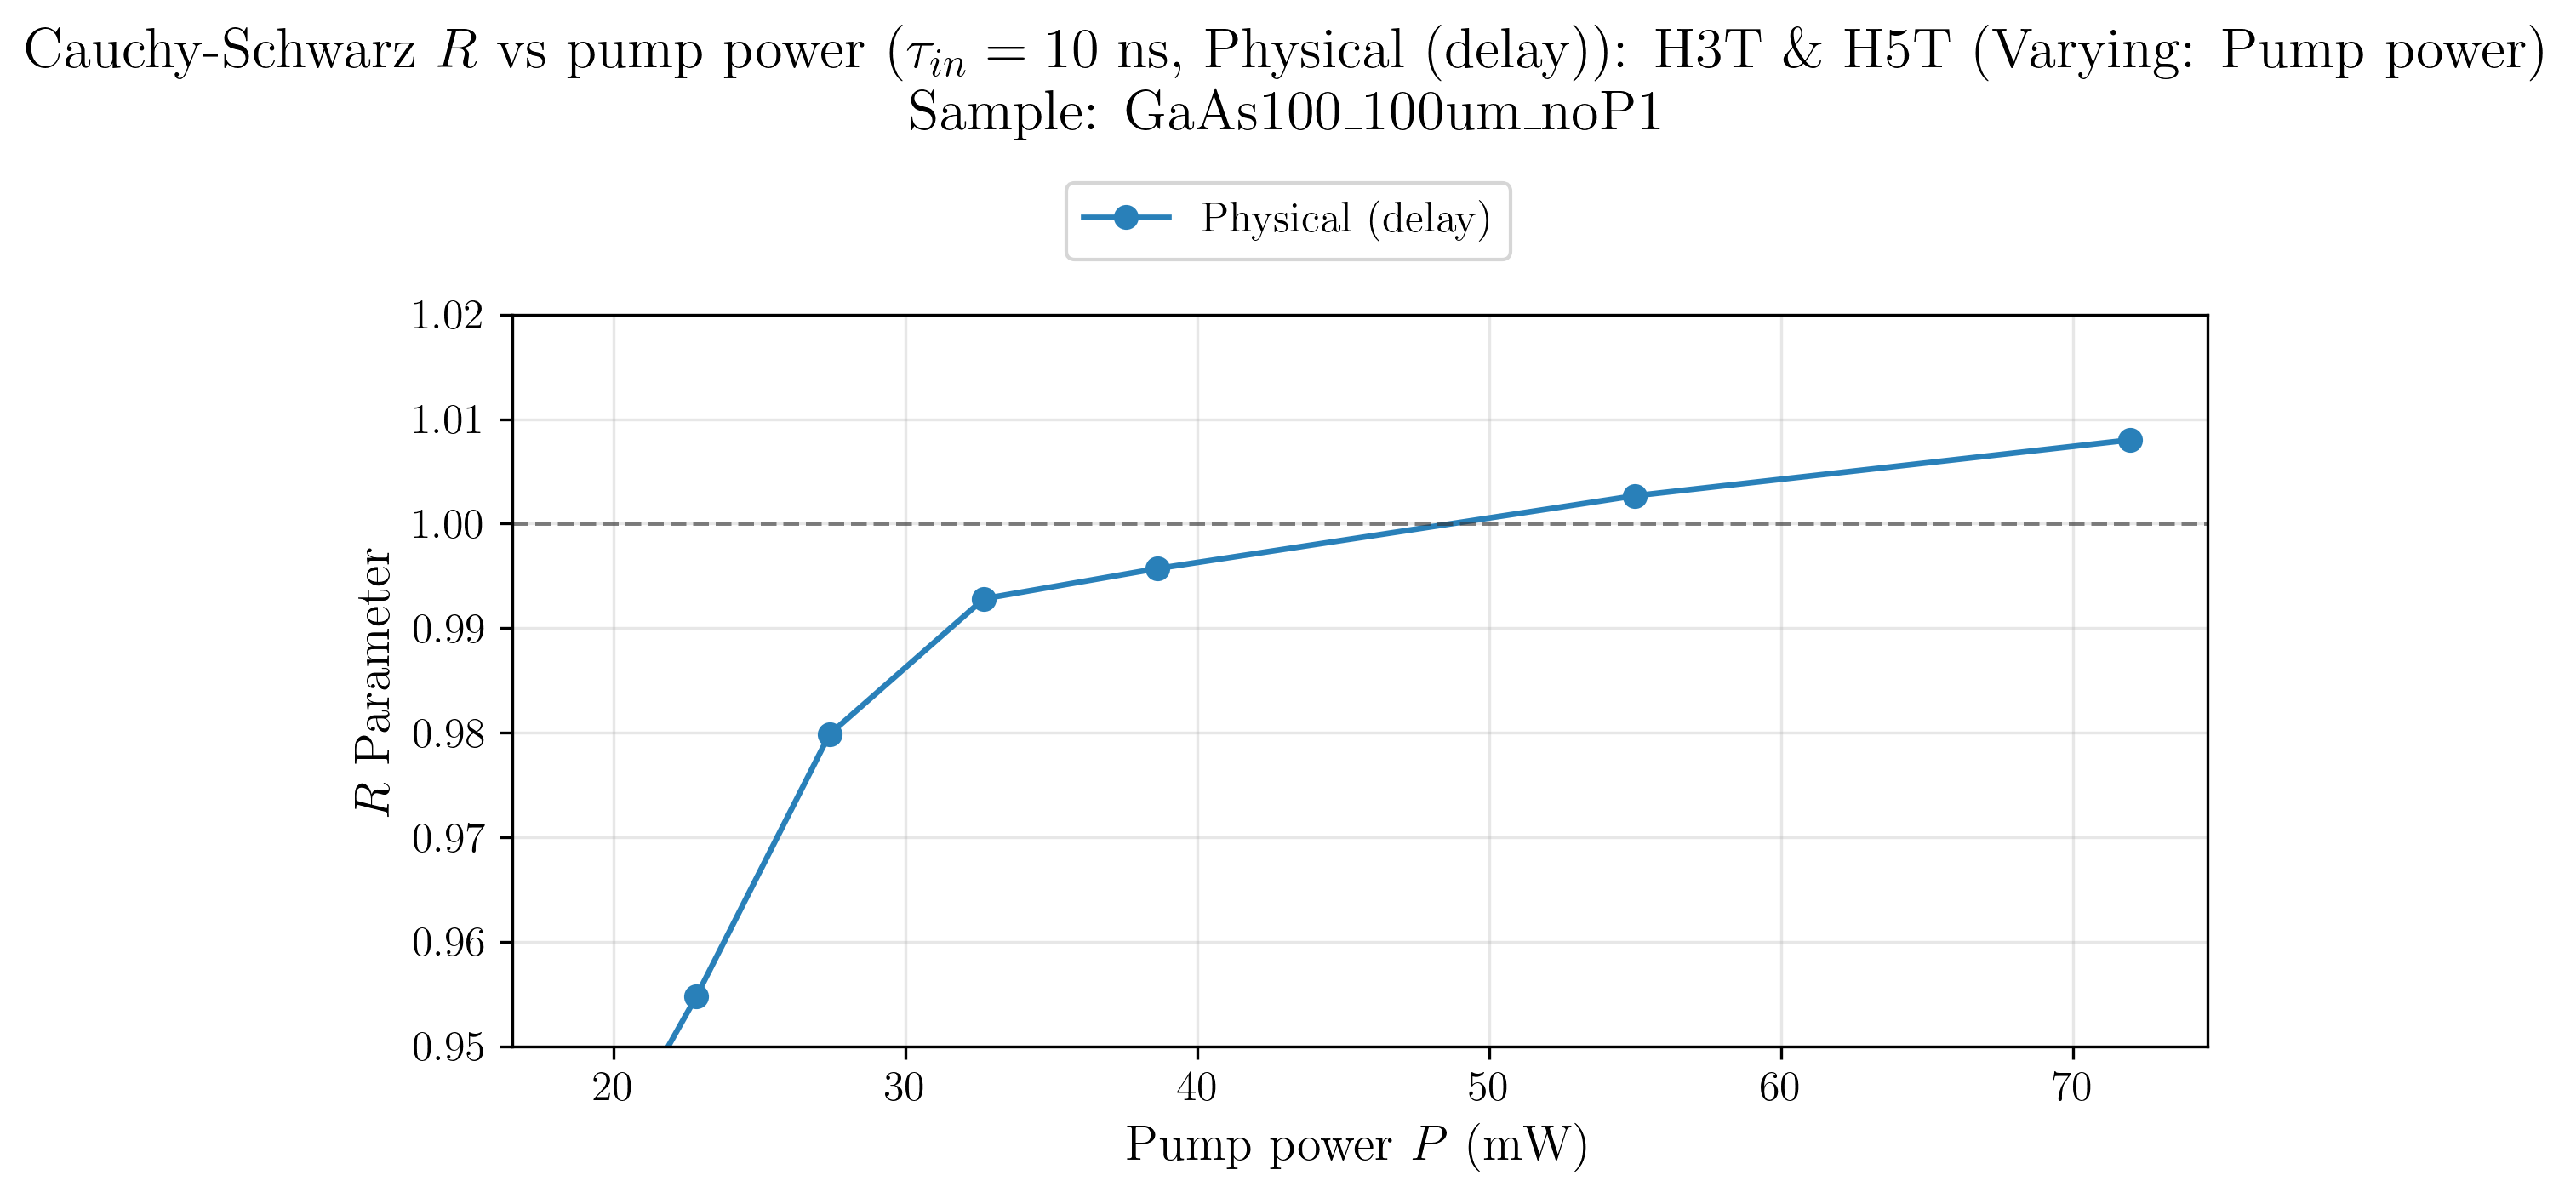

(<Figure size 2400x1500 with 1 Axes>,
 <Axes: xlabel='Pump power $P$ (mW)', ylabel='$R$ Parameter'>)

In [11]:
ch3T = runs[0].get_ch("H3T")
ch3R = runs[0].get_ch("H3R")
ch5T = runs[0].get_ch("H5T")
ch5R = runs[0].get_ch("H5R")

# 2. Pass these objects into the power scan method
comp.plot_power_scan_R(
    cross_pair=(ch3T, ch5T),
    auto_pair_1=(ch3R, ch3T),
    auto_pair_2=(ch5R, ch5T),
    tau_in_ns=10.0,
    method='delay',
    ylim=(0.95, 1.02) # Fits the R_35 scaling beautifully based on your grid result
)